# FLIR Proxy v18 Subgroup Split Analysis

This notebook diagnoses whether `data/raw/flir_private_proxy_alignment_v18`
supports subgroup-based benchmark splits.

Benchmark framing:

- Original benchmark unit: raw person count.
- New benchmark unit: subgroup regimes.
- Phase 1 subgroup: `(class, size_bin)`.
- Phase 2 subgroup: `(class, size_bin, position_bin)`.

The notebook:

- inspects the actual repository dataset layout before loading data,
- builds minimal repo-aware tables from the discovered schema,
- measures subgroup prevalence, dominance, collateral loss, and regime shift,
- and summarizes which subgroups look benchmark-feasible.



In [20]:
from __future__ import annotations

import json
import math
import random
import sys
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display


def _resolve_repo_root() -> Path:
    try:
        from src.core.paths import repo_root as _repo_root

        return _repo_root()
    except Exception:
        start = Path.cwd().resolve()
        for candidate in [start, *start.parents]:
            if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
                return candidate
        raise RuntimeError("Could not resolve repository root from the current environment.")


REPO_ROOT = _resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

try:
    from src.core.paths import flir_root as repo_flir_root
except Exception:
    repo_flir_root = None


SEED = 7
random.seed(SEED)
np.random.seed(SEED)

plt.style.use("default")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

DATA_ROOT = repo_flir_root() if callable(repo_flir_root) else REPO_ROOT / "data" / "raw" / "flir_private_proxy_alignment_v18"
REFERENCE_ROOT = REPO_ROOT / "data" / "raw" / "v18"
PREFERRED_SPLITS = ("train", "val", "test")
ANALYSIS_SPLITS = ["train"]
SIZE_BIN_METHOD = "quantile"
SIZE_BIN_LABELS = ("small", "medium", "large")
FIXED_SIZE_BINS = None
POSITION_MODE = "horizontal"
DOMINANCE_THRESHOLDS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
PHASE1_SELECTED_SUBGROUP = None
PHASE2_SELECTED_SUBGROUP = None
TOP_N_SUBGROUPS_TO_PLOT = 24
MAX_EXAMPLE_SUBGROUPS = 4

FEASIBILITY_RULES = {
    "min_instances": 100,
    "min_images": 40,
    "min_median_dominance": 0.50,
    "min_holdout_images_tau_0_5": 25,
    "max_collateral_other_loss_frac_tau_0_5": 0.35,
}

IMAGE_EXTENSIONS = {".npy", ".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

display(
    Markdown(
        "\n".join(
            [
                "**Environment**",
                "",
                f"- `REPO_ROOT`: `{REPO_ROOT}`",
                f"- `DATA_ROOT`: `{DATA_ROOT}`",
                f"- `REFERENCE_ROOT`: `{REFERENCE_ROOT}`",
                f"- `ANALYSIS_SPLITS`: `{tuple(ANALYSIS_SPLITS)}`",
                f"- `SIZE_BIN_METHOD`: `{SIZE_BIN_METHOD}`",
                f"- `POSITION_MODE`: `{POSITION_MODE}`",
                f"- `DOMINANCE_THRESHOLDS`: `{DOMINANCE_THRESHOLDS}`",
            ]
        )
    )
)




**Environment**

- `REPO_ROOT`: `/projets/Fbassignana/diffusers_try/flow_matching_trial`
- `DATA_ROOT`: `/projets/Fbassignana/diffusers_try/flow_matching_trial/data/raw/flir_private_proxy_alignment_v18`
- `REFERENCE_ROOT`: `/projets/Fbassignana/diffusers_try/flow_matching_trial/data/raw/v18`
- `ANALYSIS_SPLITS`: `('train',)`
- `SIZE_BIN_METHOD`: `quantile`
- `POSITION_MODE`: `horizontal`
- `DOMINANCE_THRESHOLDS`: `[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]`

## Dataset inspection

The loader first inspects the FLIR-alignment root and each split directory.
It discovers COCO-style annotations, image payloads, captions, and optional
metadata files instead of assuming exact filenames.



In [21]:
def load_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def load_jsonl_preview(path: Path, n_rows: int = 3) -> pd.DataFrame:
    rows: List[dict] = []
    with path.open("r", encoding="utf-8") as f:
        for idx, line in enumerate(f):
            rows.append(json.loads(line))
            if idx + 1 >= n_rows:
                break
    return pd.DataFrame(rows)


def looks_like_coco(payload: dict) -> bool:
    return isinstance(payload, dict) and {"images", "annotations", "categories"}.issubset(payload.keys())


def find_coco_annotation_files(split_dir: Path) -> List[Path]:
    candidates: List[Path] = []
    for path in sorted(split_dir.rglob("*.json")):
        try:
            payload = load_json(path)
        except Exception:
            continue
        if looks_like_coco(payload):
            candidates.append(path)
    return candidates


def choose_best_annotation_file(split_dir: Path) -> Path:
    candidates = find_coco_annotation_files(split_dir)
    if not candidates:
        raise FileNotFoundError(f"No COCO-style annotation JSON found under: {split_dir}")
    candidates = sorted(
        candidates,
        key=lambda p: (
            "annotation" not in p.name.lower(),
            len(p.relative_to(split_dir).parts),
            len(str(p)),
        ),
    )
    return candidates[0]


def list_image_files(split_dir: Path) -> List[Path]:
    return sorted(path for path in split_dir.rglob("*") if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS)


def normalize_rel_path(path: str | Path) -> str:
    return Path(path).as_posix()


@dataclass
class ImageLookup:
    by_rel_path: Dict[str, Path]
    by_name: Dict[str, Path]
    by_stem: Dict[str, Path]


def build_image_lookup(image_files: Sequence[Path], split_dir: Path) -> ImageLookup:
    by_rel_path: Dict[str, Path] = {}
    by_name: Dict[str, Path] = {}
    by_stem: Dict[str, Path] = {}
    for path in image_files:
        rel_path = normalize_rel_path(path.relative_to(split_dir))
        by_rel_path.setdefault(rel_path, path)
        by_name.setdefault(path.name, path)
        by_stem.setdefault(path.stem, path)
    return ImageLookup(by_rel_path=by_rel_path, by_name=by_name, by_stem=by_stem)


def resolve_image_path(file_name: str | None, split_dir: Path, lookup: ImageLookup) -> Optional[Path]:
    if not file_name:
        return None
    candidates = [
        normalize_rel_path(file_name),
        normalize_rel_path(Path(file_name).name),
    ]
    for candidate in candidates:
        if candidate in lookup.by_rel_path:
            return lookup.by_rel_path[candidate]
        if candidate in lookup.by_name:
            return lookup.by_name[candidate]
    stem = Path(file_name).stem
    return lookup.by_stem.get(stem)


def discover_split_dirs(data_root: Path, preferred_splits: Sequence[str] = PREFERRED_SPLITS) -> List[Path]:
    if not data_root.exists():
        raise FileNotFoundError(f"Dataset root does not exist: {data_root}")

    ordered: List[Path] = []
    seen: set[Path] = set()
    for split in preferred_splits:
        split_dir = data_root / split
        if split_dir.is_dir():
            ordered.append(split_dir)
            seen.add(split_dir)

    for child in sorted(data_root.iterdir()):
        if child.is_dir() and child not in seen:
            try:
                has_annotations = bool(find_coco_annotation_files(child))
            except Exception:
                has_annotations = False
            if has_annotations:
                ordered.append(child)

    return ordered


def inspect_dataset_root(data_root: Path) -> Tuple[pd.DataFrame, pd.DataFrame]:
    split_dirs = discover_split_dirs(data_root)
    if not split_dirs:
        raise FileNotFoundError(f"No candidate split directories found under: {data_root}")

    split_rows: List[dict] = []
    for split_dir in split_dirs:
        image_files = list_image_files(split_dir)
        ann_path = choose_best_annotation_file(split_dir)
        coco = load_json(ann_path)
        lookup = build_image_lookup(image_files, split_dir)

        referenced_paths = [img.get("file_name") for img in coco.get("images", [])]
        resolved_paths = [resolve_image_path(name, split_dir, lookup) for name in referenced_paths]
        missing_count = sum(path is None for path in resolved_paths)
        category_names = [cat.get("name", cat.get("id")) for cat in coco.get("categories", [])]

        split_rows.append(
            {
                "split": split_dir.name,
                "split_dir": str(split_dir),
                "annotation_path": str(ann_path),
                "captions_path": str(split_dir / "captions.json") if (split_dir / "captions.json").exists() else None,
                "n_images_json": len(coco.get("images", [])),
                "n_annotations_json": len(coco.get("annotations", [])),
                "n_categories": len(coco.get("categories", [])),
                "category_names": ", ".join(map(str, category_names)),
                "n_image_files_disk": len(image_files),
                "image_extensions": ", ".join(sorted({path.suffix.lower() for path in image_files})),
                "n_missing_referenced_images": missing_count,
            }
        )

    metadata_rows: List[dict] = []
    for meta_path in sorted(data_root.glob("metadata*.jsonl")):
        preview = load_jsonl_preview(meta_path, n_rows=1)
        metadata_rows.append(
            {
                "path": str(meta_path),
                "n_preview_rows": len(preview),
                "preview_columns": ", ".join(preview.columns.tolist()),
            }
        )

    split_df = pd.DataFrame(split_rows).sort_values("split").reset_index(drop=True)
    metadata_df = pd.DataFrame(metadata_rows)
    return split_df, metadata_df


dataset_layout_df, root_metadata_df = inspect_dataset_root(DATA_ROOT)
display(dataset_layout_df)

if root_metadata_df.empty:
    print(f"No root-level metadata.jsonl found under {DATA_ROOT}.")
else:
    display(root_metadata_df)

available_splits = dataset_layout_df["split"].tolist()
print("Available splits:", available_splits)




,split,split_dir,annotation_path,captions_path,n_images_json,n_annotations_json,n_categories,category_names,n_image_files_disk,image_extensions,n_missing_referenced_images
0,test,/projets/Fbassignana/diffusers_try/flow_matchi...,/projets/Fbassignana/diffusers_try/flow_matchi...,None,1613,41340,16,"person, bike, car, motor, bus, train, truck, l...",1613,.npy,0
1,train,/projets/Fbassignana/diffusers_try/flow_matchi...,/projets/Fbassignana/diffusers_try/flow_matchi...,/projets/Fbassignana/diffusers_try/flow_matchi...,4620,83264,16,"person, bike, car, motor, bus, train, truck, l...",4620,.npy,0
2,val,/projets/Fbassignana/diffusers_try/flow_matchi...,/projets/Fbassignana/diffusers_try/flow_matchi...,None,492,10265,16,"person, bike, car, motor, bus, train, truck, l...",492,.npy,0


No root-level metadata.jsonl found under /projets/Fbassignana/diffusers_try/flow_matching_trial/data/raw/flir_private_proxy_alignment_v18.
Available splits: ['test', 'train', 'val']


## Loader layer

The loader builds explicit image-level and instance-level tables from the
discovered split layout. It keeps paths and filenames as found on disk and
fails early if requested splits are missing required annotation files.



In [22]:
def load_captions_if_present(split_dir: Path) -> Dict[str, str]:
    captions_path = split_dir / "captions.json"
    if not captions_path.exists():
        return {}
    payload = load_json(captions_path)
    if isinstance(payload, dict):
        return {str(k): str(v) for k, v in payload.items()}
    raise ValueError(f"Unsupported captions schema in: {captions_path}")


def coerce_bbox_xywh(raw_bbox: Sequence[float]) -> Tuple[float, float, float, float]:
    if len(raw_bbox) != 4:
        raise ValueError(f"Expected bbox with 4 values, got {raw_bbox!r}")
    x, y, w, h = map(float, raw_bbox)
    return x, y, w, h


def build_split_tables(split_record: pd.Series) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[int, str]]:
    split = str(split_record["split"])
    split_dir = Path(split_record["split_dir"])
    ann_path = Path(split_record["annotation_path"])
    coco = load_json(ann_path)

    image_files = list_image_files(split_dir)
    lookup = build_image_lookup(image_files, split_dir)
    captions = load_captions_if_present(split_dir)
    category_name_by_id = {int(cat["id"]): str(cat.get("name", cat["id"])) for cat in coco.get("categories", [])}

    image_rows: List[dict] = []
    image_meta_by_id: Dict[str, dict] = {}
    for image in coco.get("images", []):
        image_id = str(image["id"])
        file_name = str(image.get("file_name", image_id))
        resolved_path = resolve_image_path(file_name, split_dir, lookup)
        width = float(image.get("width", np.nan))
        height = float(image.get("height", np.nan))
        image_area = width * height if np.isfinite(width) and np.isfinite(height) else np.nan
        image_key = f"{split}::{image_id}"
        image_meta = {
            "split": split,
            "image_id": image_id,
            "image_key": image_key,
            "file_name": file_name,
            "file_path": str(resolved_path) if resolved_path is not None else None,
            "image_exists": resolved_path is not None and resolved_path.exists(),
            "image_width": width,
            "image_height": height,
            "image_area": image_area,
            "caption": captions.get(image_id),
        }
        image_meta_by_id[image_id] = image_meta
        image_rows.append(image_meta)

    instance_rows: List[dict] = []
    for ann in coco.get("annotations", []):
        image_id = str(ann["image_id"])
        if image_id not in image_meta_by_id:
            continue
        x, y, w, h = coerce_bbox_xywh(ann["bbox"])
        meta = image_meta_by_id[image_id]
        image_width = float(meta["image_width"])
        image_height = float(meta["image_height"])
        image_area = float(meta["image_area"])
        bbox_area = float(max(w, 0.0) * max(h, 0.0))
        bbox_area_norm = bbox_area / image_area if image_area > 0 else np.nan
        bbox_center_x = x + 0.5 * w
        bbox_center_y = y + 0.5 * h
        bbox_center_x_norm = bbox_center_x / image_width if image_width > 0 else np.nan
        bbox_center_y_norm = bbox_center_y / image_height if image_height > 0 else np.nan
        instance_rows.append(
            {
                "split": split,
                "image_id": image_id,
                "image_key": meta["image_key"],
                "file_name": meta["file_name"],
                "file_path": meta["file_path"],
                "class_id": int(ann["category_id"]),
                "class_label": category_name_by_id.get(int(ann["category_id"]), str(ann["category_id"])),
                "ann_id": ann["id"],
                "bbox_x": x,
                "bbox_y": y,
                "bbox_w": w,
                "bbox_h": h,
                "bbox_area": bbox_area,
                "bbox_area_norm": bbox_area_norm,
                "bbox_center_x": bbox_center_x,
                "bbox_center_y": bbox_center_y,
                "bbox_center_x_norm": bbox_center_x_norm,
                "bbox_center_y_norm": bbox_center_y_norm,
                "image_width": image_width,
                "image_height": image_height,
                "image_area": image_area,
                "iscrowd": int(ann.get("iscrowd", 0)),
            }
        )

    image_df = pd.DataFrame(image_rows)
    instance_df = pd.DataFrame(instance_rows)
    if image_df.empty:
        raise ValueError(f"No image records were loaded from: {ann_path}")
    if instance_df.empty:
        warnings.warn(f"No annotation rows were loaded from: {ann_path}")

    return image_df, instance_df, category_name_by_id


def load_dataset_tables(layout_df: pd.DataFrame, selected_splits: Sequence[str]) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    missing_splits = sorted(set(selected_splits) - set(layout_df["split"].tolist()))
    if missing_splits:
        raise ValueError(f"Requested splits are unavailable: {missing_splits}")

    image_tables: List[pd.DataFrame] = []
    instance_tables: List[pd.DataFrame] = []
    category_rows: List[dict] = []

    for split in selected_splits:
        split_record = layout_df.loc[layout_df["split"] == split]
        if split_record.empty:
            raise ValueError(f"Split not found in layout table: {split}")
        image_df, instance_df, category_name_by_id = build_split_tables(split_record.iloc[0])
        image_tables.append(image_df)
        instance_tables.append(instance_df)
        for category_id, category_name in category_name_by_id.items():
            category_rows.append(
                {
                    "split": split,
                    "class_id": int(category_id),
                    "class_label": str(category_name),
                }
            )

    full_image_df = pd.concat(image_tables, ignore_index=True)
    full_instance_df = pd.concat(instance_tables, ignore_index=True)
    category_df = pd.DataFrame(category_rows).drop_duplicates().sort_values(["split", "class_id"]).reset_index(drop=True)

    ann_counts = full_instance_df.groupby("image_key").size().rename("n_annotations")
    full_image_df = full_image_df.merge(ann_counts, on="image_key", how="left")
    full_image_df["n_annotations"] = full_image_df["n_annotations"].fillna(0).astype(int)

    return full_image_df, full_instance_df, category_df


image_table, instance_table_raw, category_table = load_dataset_tables(dataset_layout_df, ANALYSIS_SPLITS)

dataset_summary_df = pd.DataFrame(
    [
        {
            "selected_splits": ", ".join(ANALYSIS_SPLITS),
            "n_images": image_table["image_key"].nunique(),
            "n_annotations": len(instance_table_raw),
            "n_classes": instance_table_raw["class_label"].nunique(),
            "classes": ", ".join(sorted(instance_table_raw["class_label"].unique())),
            "n_missing_image_files": int((~image_table["image_exists"]).sum()),
        }
    ]
)

display(dataset_summary_df)
display(category_table.head(20))
display(instance_table_raw.head(5))




,selected_splits,n_images,n_annotations,n_classes,classes,n_missing_image_files
0,train,4620,83264,16,"bike, bus, car, deer, dog, hydrant, light, mot...",0


,split,class_id,class_label
0,train,0,person
1,train,1,bike
2,train,2,car
3,train,3,motor
4,train,4,bus
5,train,5,train
6,train,6,truck
7,train,7,light
8,train,8,hydrant
9,train,9,sign


,split,image_id,image_key,file_name,file_path,class_id,class_label,ann_id,bbox_x,bbox_y,...,bbox_area,bbox_area_norm,bbox_center_x,bbox_center_y,bbox_center_x_norm,bbox_center_y_norm,image_width,image_height,image_area,iscrowd
0,train,video-GzdKTLbkG5F7gAunM-frame-000108-QHZmA4QTZ...,train::video-GzdKTLbkG5F7gAunM-frame-000108-QH...,video-GzdKTLbkG5F7gAunM-frame-000108-QHZmA4QTZ...,/projets/Fbassignana/diffusers_try/flow_matchi...,7,light,0,533.0,114.0,...,748.0,0.002283,541.5,136.0,0.846094,0.265625,640.0,512.0,327680.0,0
1,train,video-GzdKTLbkG5F7gAunM-frame-000108-QHZmA4QTZ...,train::video-GzdKTLbkG5F7gAunM-frame-000108-QH...,video-GzdKTLbkG5F7gAunM-frame-000108-QHZmA4QTZ...,/projets/Fbassignana/diffusers_try/flow_matchi...,7,light,1,507.0,110.0,...,675.0,0.002060,514.5,132.5,0.803906,0.258789,640.0,512.0,327680.0,0
2,train,video-GzdKTLbkG5F7gAunM-frame-000108-QHZmA4QTZ...,train::video-GzdKTLbkG5F7gAunM-frame-000108-QH...,video-GzdKTLbkG5F7gAunM-frame-000108-QHZmA4QTZ...,/projets/Fbassignana/diffusers_try/flow_matchi...,7,light,2,183.0,2.0,...,1512.0,0.004614,196.5,30.0,0.307031,0.058594,640.0,512.0,327680.0,0
3,train,video-GzdKTLbkG5F7gAunM-frame-000108-QHZmA4QTZ...,train::video-GzdKTLbkG5F7gAunM-frame-000108-QH...,video-GzdKTLbkG5F7gAunM-frame-000108-QHZmA4QTZ...,/projets/Fbassignana/diffusers_try/flow_matchi...,7,light,3,537.0,178.0,...,255.0,0.000778,544.5,186.5,0.850781,0.364258,640.0,512.0,327680.0,0
4,train,video-GzdKTLbkG5F7gAunM-frame-000108-QHZmA4QTZ...,train::video-GzdKTLbkG5F7gAunM-frame-000108-QH...,video-GzdKTLbkG5F7gAunM-frame-000108-QHZmA4QTZ...,/projets/Fbassignana/diffusers_try/flow_matchi...,9,sign,4,344.0,76.0,...,1240.0,0.003784,375.0,86.0,0.585938,0.167969,640.0,512.0,327680.0,0


## Feature engineering

This section constructs normalized size features, position bins, subgroup
labels, and image-level subgroup statistics used by all downstream analyses.



In [23]:
def assign_size_bins(
    instance_df: pd.DataFrame,
    *,
    method: str = "quantile",
    labels: Sequence[str] = SIZE_BIN_LABELS,
    fixed_bins: Optional[Sequence[float]] = FIXED_SIZE_BINS,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df = instance_df.copy()
    values = df["bbox_area_norm"].astype(float).clip(lower=0.0)

    if method == "quantile":
        ranked = values.rank(method="first")
        df["size_bin"] = pd.qcut(ranked, q=len(labels), labels=list(labels))
        bin_spec = (
            df.groupby("size_bin", observed=True)["bbox_area_norm"]
            .agg(bin_min="min", bin_max="max", n_instances="size")
            .reset_index()
        )
        bin_spec["method"] = method
    elif method == "fixed":
        if fixed_bins is None:
            raise ValueError("Fixed size bins were requested but `fixed_bins` is None.")
        if len(fixed_bins) != len(labels) + 1:
            raise ValueError("Fixed size bins must have len(labels) + 1 edges.")
        df["size_bin"] = pd.cut(values, bins=fixed_bins, labels=list(labels), include_lowest=True)
        bin_spec = pd.DataFrame(
            {
                "size_bin": list(labels),
                "bin_min": list(fixed_bins[:-1]),
                "bin_max": list(fixed_bins[1:]),
                "method": method,
            }
        )
        counts = df["size_bin"].value_counts(dropna=False).rename_axis("size_bin").reset_index(name="n_instances")
        bin_spec = bin_spec.merge(counts, on="size_bin", how="left")
    else:
        raise ValueError(f"Unsupported size bin method: {method}")

    return df, bin_spec


def add_position_columns(instance_df: pd.DataFrame) -> pd.DataFrame:
    df = instance_df.copy()
    x = df["bbox_center_x_norm"].astype(float).clip(0.0, 1.0)
    y = df["bbox_center_y_norm"].astype(float).clip(0.0, 1.0)

    horizontal_labels = ["left", "center", "right"]
    vertical_labels = ["top", "middle", "bottom"]
    bins = [0.0, 1.0 / 3.0, 2.0 / 3.0, 1.0]

    df["position_bin_horizontal"] = pd.cut(x, bins=bins, labels=horizontal_labels, include_lowest=True)
    df["position_bin_vertical"] = pd.cut(y, bins=bins, labels=vertical_labels, include_lowest=True)
    df["position_bin_grid"] = (
        df["position_bin_vertical"].astype(str) + "_" + df["position_bin_horizontal"].astype(str)
    )

    center_distance = np.sqrt((x - 0.5) ** 2 + (y - 0.5) ** 2)
    df["center_distance_norm"] = center_distance / math.sqrt(0.5**2 + 0.5**2)
    return df


def build_subgroup_labels(
    instance_df: pd.DataFrame,
    *,
    include_position: bool = False,
    position_mode: str = POSITION_MODE,
) -> pd.DataFrame:
    df = instance_df.copy()
    components = [
        "class=" + df["class_label"].astype(str),
        "size=" + df["size_bin"].astype(str),
    ]
    if include_position:
        if position_mode == "horizontal":
            position_values = df["position_bin_horizontal"].astype(str)
        elif position_mode == "grid_3x3":
            position_values = df["position_bin_grid"].astype(str)
        else:
            raise ValueError(f"Unsupported position mode: {position_mode}")
        components.append("pos=" + position_values)

    subgroup = components[0]
    for component in components[1:]:
        subgroup = subgroup + " | " + component
    df["subgroup"] = subgroup
    return df


def compute_image_level_subgroup_stats(
    image_df: pd.DataFrame,
    subgroup_df: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    image_base = image_df.copy()

    if subgroup_df.empty:
        empty_subgroups = pd.DataFrame(
            columns=[
                "image_key",
                "split",
                "image_id",
                "subgroup",
                "subgroup_count",
                "total_object_count",
                "dominance_ratio",
                "image_density",
                "is_dominant",
            ]
        )
        image_base["total_object_count"] = 0
        image_base["n_subgroups_present"] = 0
        image_base["total_bbox_area"] = 0.0
        image_base["image_density"] = 0.0
        image_base["dominant_subgroup"] = np.nan
        image_base["dominant_subgroup_count"] = 0
        image_base["dominant_ratio"] = 0.0
        image_base["dominant_tie_count"] = 0
        return image_base, empty_subgroups

    image_totals = (
        subgroup_df.groupby("image_key")
        .agg(
            total_object_count=("ann_id", "size"),
            n_subgroups_present=("subgroup", "nunique"),
            total_bbox_area=("bbox_area", "sum"),
        )
        .reset_index()
    )
    image_totals["image_density"] = image_totals["total_bbox_area"] / image_base.set_index("image_key").loc[image_totals["image_key"], "image_area"].to_numpy()

    image_subgroup_df = (
        subgroup_df.groupby(["image_key", "split", "image_id", "subgroup"])
        .size()
        .rename("subgroup_count")
        .reset_index()
    )
    image_subgroup_df = image_subgroup_df.merge(image_totals, on="image_key", how="left")
    image_subgroup_df["dominance_ratio"] = image_subgroup_df["subgroup_count"] / image_subgroup_df["total_object_count"]

    max_count = image_subgroup_df.groupby("image_key")["subgroup_count"].transform("max")
    image_subgroup_df["is_at_max_count"] = image_subgroup_df["subgroup_count"] == max_count
    dominant_tie_count = image_subgroup_df.groupby("image_key")["is_at_max_count"].sum().rename("dominant_tie_count")

    dominant_rows = (
        image_subgroup_df.sort_values(
            ["image_key", "subgroup_count", "dominance_ratio", "subgroup"],
            ascending=[True, False, False, True],
        )
        .groupby("image_key")
        .head(1)
        .rename(
            columns={
                "subgroup": "dominant_subgroup",
                "subgroup_count": "dominant_subgroup_count",
                "dominance_ratio": "dominant_ratio",
            }
        )[
            ["image_key", "dominant_subgroup", "dominant_subgroup_count", "dominant_ratio"]
        ]
    )

    image_subgroup_df = image_subgroup_df.merge(dominant_rows[["image_key", "dominant_subgroup"]], on="image_key", how="left")
    image_subgroup_df["is_dominant"] = image_subgroup_df["subgroup"] == image_subgroup_df["dominant_subgroup"]

    image_stats_df = image_base.merge(image_totals, on="image_key", how="left")
    image_stats_df = image_stats_df.merge(dominant_rows, on="image_key", how="left")
    image_stats_df = image_stats_df.merge(dominant_tie_count.reset_index(), on="image_key", how="left")

    fill_zero_cols = [
        "total_object_count",
        "n_subgroups_present",
        "total_bbox_area",
        "image_density",
        "dominant_subgroup_count",
        "dominant_ratio",
        "dominant_tie_count",
    ]
    for column in fill_zero_cols:
        image_stats_df[column] = image_stats_df[column].fillna(0)

    return image_stats_df, image_subgroup_df


def build_analysis_tables(
    image_df: pd.DataFrame,
    instance_df: pd.DataFrame,
    *,
    size_bin_method: str = SIZE_BIN_METHOD,
    size_bin_labels: Sequence[str] = SIZE_BIN_LABELS,
    fixed_size_bins: Optional[Sequence[float]] = FIXED_SIZE_BINS,
    include_position: bool = False,
    position_mode: str = POSITION_MODE,
) -> Dict[str, pd.DataFrame]:
    sized_df, size_bin_spec_df = assign_size_bins(
        instance_df,
        method=size_bin_method,
        labels=size_bin_labels,
        fixed_bins=fixed_size_bins,
    )
    positioned_df = add_position_columns(sized_df)
    subgroup_df = build_subgroup_labels(positioned_df, include_position=include_position, position_mode=position_mode)
    image_stats_df, image_subgroup_df = compute_image_level_subgroup_stats(image_df, subgroup_df)
    return {
        "size_bin_spec_df": size_bin_spec_df,
        "instance_df": subgroup_df,
        "image_stats_df": image_stats_df,
        "image_subgroup_df": image_subgroup_df,
    }


phase1_tables = build_analysis_tables(
    image_table,
    instance_table_raw,
    size_bin_method=SIZE_BIN_METHOD,
    size_bin_labels=SIZE_BIN_LABELS,
    fixed_size_bins=FIXED_SIZE_BINS,
    include_position=False,
)

size_bin_spec_df = phase1_tables["size_bin_spec_df"]
phase1_instance_table = phase1_tables["instance_df"]
phase1_image_stats_df = phase1_tables["image_stats_df"]
phase1_image_subgroup_df = phase1_tables["image_subgroup_df"]

display(size_bin_spec_df)
display(phase1_instance_table.head(5))
display(phase1_image_stats_df.head(5))




,size_bin,bin_min,bin_max,n_instances,method
0,small,0.000003,0.000476,27755,quantile
1,medium,0.000476,0.002301,27754,quantile
2,large,0.002301,0.623706,27755,quantile


,split,image_id,image_key,file_name,file_path,class_id,class_label,ann_id,bbox_x,bbox_y,...,image_width,image_height,image_area,iscrowd,size_bin,position_bin_horizontal,position_bin_vertical,position_bin_grid,center_distance_norm,subgroup
0,train,video-GzdKTLbkG5F7gAunM-frame-000108-QHZmA4QTZ...,train::video-GzdKTLbkG5F7gAunM-frame-000108-QH...,video-GzdKTLbkG5F7gAunM-frame-000108-QHZmA4QTZ...,/projets/Fbassignana/diffusers_try/flow_matchi...,7,light,0,533.0,114.0,...,640.0,512.0,327680.0,0,medium,right,top,top_right,0.591122,class=light | size=medium
1,train,video-GzdKTLbkG5F7gAunM-frame-000108-QHZmA4QTZ...,train::video-GzdKTLbkG5F7gAunM-frame-000108-QH...,video-GzdKTLbkG5F7gAunM-frame-000108-QHZmA4QTZ...,/projets/Fbassignana/diffusers_try/flow_matchi...,7,light,1,507.0,110.0,...,640.0,512.0,327680.0,0,medium,right,top,top_right,0.548711,class=light | size=medium
2,train,video-GzdKTLbkG5F7gAunM-frame-000108-QHZmA4QTZ...,train::video-GzdKTLbkG5F7gAunM-frame-000108-QH...,video-GzdKTLbkG5F7gAunM-frame-000108-QHZmA4QTZ...,/projets/Fbassignana/diffusers_try/flow_matchi...,7,light,2,183.0,2.0,...,640.0,512.0,327680.0,0,large,left,top,top_left,0.681288,class=light | size=large
3,train,video-GzdKTLbkG5F7gAunM-frame-000108-QHZmA4QTZ...,train::video-GzdKTLbkG5F7gAunM-frame-000108-QH...,video-GzdKTLbkG5F7gAunM-frame-000108-QHZmA4QTZ...,/projets/Fbassignana/diffusers_try/flow_matchi...,7,light,3,537.0,178.0,...,640.0,512.0,327680.0,0,medium,right,middle,middle_right,0.531927,class=light | size=medium
4,train,video-GzdKTLbkG5F7gAunM-frame-000108-QHZmA4QTZ...,train::video-GzdKTLbkG5F7gAunM-frame-000108-QH...,video-GzdKTLbkG5F7gAunM-frame-000108-QHZmA4QTZ...,/projets/Fbassignana/diffusers_try/flow_matchi...,9,sign,4,344.0,76.0,...,640.0,512.0,327680.0,0,large,center,top,top_center,0.485036,class=sign | size=large


,split,image_id,image_key,file_name,file_path,image_exists,image_width,image_height,image_area,caption,n_annotations,total_object_count,n_subgroups_present,total_bbox_area,image_density,dominant_subgroup,dominant_subgroup_count,dominant_ratio,dominant_tie_count
0,train,video-24ysbPEGoEKKDvRt6-frame-000255-Y56C5LQh4...,train::video-24ysbPEGoEKKDvRt6-frame-000255-Y5...,video-24ysbPEGoEKKDvRt6-frame-000255-Y56C5LQh4...,/projets/Fbassignana/diffusers_try/flow_matchi...,True,640.0,512.0,327680.0,"overhead infrared surveillance image, circular...",22,22,7,91920.0,0.280518,class=person | size=medium,7,0.318182,1
1,train,video-24ysbPEGoEKKDvRt6-frame-000270-AFJ2A96Mg...,train::video-24ysbPEGoEKKDvRt6-frame-000270-AF...,video-24ysbPEGoEKKDvRt6-frame-000270-AFJ2A96Mg...,/projets/Fbassignana/diffusers_try/flow_matchi...,True,640.0,512.0,327680.0,"overhead infrared surveillance image, circular...",22,22,6,87696.0,0.267627,class=person | size=medium,11,0.500000,1
2,train,video-24ysbPEGoEKKDvRt6-frame-000285-ijGWHCEET...,train::video-24ysbPEGoEKKDvRt6-frame-000285-ij...,video-24ysbPEGoEKKDvRt6-frame-000285-ijGWHCEET...,/projets/Fbassignana/diffusers_try/flow_matchi...,True,640.0,512.0,327680.0,"overhead infrared surveillance image, circular...",21,21,7,84432.0,0.257666,class=person | size=medium,7,0.333333,1
3,train,video-24ysbPEGoEKKDvRt6-frame-000675-EoyDxYnrK...,train::video-24ysbPEGoEKKDvRt6-frame-000675-Eo...,video-24ysbPEGoEKKDvRt6-frame-000675-EoyDxYnrK...,/projets/Fbassignana/diffusers_try/flow_matchi...,True,640.0,512.0,327680.0,"overhead infrared surveillance image, circular...",21,21,10,25129.0,0.076688,class=car | size=large,4,0.190476,2
4,train,video-24ysbPEGoEKKDvRt6-frame-000690-fe7PhqNPz...,train::video-24ysbPEGoEKKDvRt6-frame-000690-fe...,video-24ysbPEGoEKKDvRt6-frame-000690-fe7PhqNPz...,/projets/Fbassignana/diffusers_try/flow_matchi...,True,640.0,512.0,327680.0,"overhead infrared surveillance image, circular...",23,23,10,26235.0,0.080063,class=sign | size=medium,5,0.217391,2


## Analysis helpers

The plotting and summary helpers below are reused for both the phase 1 and
phase 2 subgroup definitions.



In [24]:
def sort_and_cap(table: pd.DataFrame, value_col: str, top_n: Optional[int] = TOP_N_SUBGROUPS_TO_PLOT) -> pd.DataFrame:
    out = table.sort_values(value_col, ascending=False)
    if top_n is not None:
        out = out.head(top_n)
    return out


def plot_bar(table: pd.DataFrame, value_col: str, title: str, color: str = "#4c78a8", figsize: Tuple[int, int] = (10, 5)) -> plt.Figure:
    fig, ax = plt.subplots(figsize=figsize)
    ordered = sort_and_cap(table, value_col)
    sns.barplot(data=ordered, x="subgroup", y=value_col, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("subgroup")
    ax.set_ylabel(value_col)
    ax.tick_params(axis="x", rotation=75)
    plt.tight_layout()
    return fig


def build_subgroup_frequency_table(instance_df: pd.DataFrame, image_subgroup_df: pd.DataFrame) -> pd.DataFrame:
    n_instances = instance_df.groupby("subgroup").size().rename("n_instances")
    n_images = image_subgroup_df.groupby("subgroup")["image_key"].nunique().rename("n_images")
    avg_present_count = image_subgroup_df.groupby("subgroup")["subgroup_count"].mean().rename("avg_instances_per_image_present")
    freq_df = pd.concat([n_instances, n_images, avg_present_count], axis=1).reset_index()
    return freq_df.sort_values(["n_instances", "n_images"], ascending=False).reset_index(drop=True)


def build_dominance_summary(image_subgroup_df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        image_subgroup_df.groupby("subgroup")["dominance_ratio"]
        .agg(
            mean_dominance="mean",
            median_dominance="median",
            q75_dominance=lambda s: float(s.quantile(0.75)),
            q90_dominance=lambda s: float(s.quantile(0.90)),
            n_images="size",
        )
        .reset_index()
    )
    return summary.sort_values(["median_dominance", "n_images"], ascending=False).reset_index(drop=True)


def build_position_profile(instance_df: pd.DataFrame) -> pd.DataFrame:
    return (
        instance_df.groupby("subgroup")
        .agg(
            n_instances=("ann_id", "size"),
            horizontal_center_share=("position_bin_horizontal", lambda s: float((s.astype(str) == "center").mean())),
            grid_center_share=("position_bin_grid", lambda s: float((s.astype(str) == "middle_center").mean())),
            mean_center_distance=("center_distance_norm", "mean"),
            median_center_distance=("center_distance_norm", "median"),
        )
        .reset_index()
        .sort_values(["horizontal_center_share", "n_instances"], ascending=[False, False])
        .reset_index(drop=True)
    )


def choose_default_subgroup(freq_df: pd.DataFrame, preferred: Optional[str] = None, min_images: int = 20) -> str:
    if preferred is not None:
        if preferred not in set(freq_df["subgroup"]):
            raise ValueError(f"Requested subgroup not found: {preferred}")
        return preferred
    candidates = freq_df.loc[freq_df["n_images"] >= min_images]
    if candidates.empty:
        candidates = freq_df
    return str(candidates.sort_values(["n_images", "n_instances"], ascending=False).iloc[0]["subgroup"])


def plot_dominance_histograms(
    image_subgroup_df: pd.DataFrame,
    subgroups: Sequence[str],
    *,
    bins: int = 20,
) -> plt.Figure:
    n_cols = min(2, len(subgroups))
    n_rows = math.ceil(len(subgroups) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3.6 * n_rows), squeeze=False)
    for ax, subgroup in zip(axes.flat, subgroups):
        subset = image_subgroup_df.loc[image_subgroup_df["subgroup"] == subgroup]
        sns.histplot(subset["dominance_ratio"], bins=bins, ax=ax, color="#4c78a8")
        ax.set_title(subgroup)
        ax.set_xlabel("dominance ratio")
        ax.set_ylabel("images")
    for ax in axes.flat[len(subgroups):]:
        ax.axis("off")
    plt.tight_layout()
    return fig


def compute_holdout_table(
    image_subgroup_df: pd.DataFrame,
    image_stats_df: pd.DataFrame,
    subgroup: str,
    thresholds: Sequence[float] = DOMINANCE_THRESHOLDS,
) -> pd.DataFrame:
    subgroup_rows = image_subgroup_df.loc[image_subgroup_df["subgroup"] == subgroup].copy()
    total_images = max(image_stats_df["image_key"].nunique(), 1)
    rows: List[dict] = []
    for tau in thresholds:
        heldout = subgroup_rows.loc[(subgroup_rows["subgroup_count"] >= 1) & (subgroup_rows["dominance_ratio"] >= tau)].copy()
        rows.append(
            {
                "subgroup": subgroup,
                "tau": float(tau),
                "heldout_n_images": int(heldout["image_key"].nunique()),
                "heldout_fraction": float(heldout["image_key"].nunique() / total_images),
                "mean_target_count": float(heldout["subgroup_count"].mean()) if not heldout.empty else 0.0,
                "median_target_count": float(heldout["subgroup_count"].median()) if not heldout.empty else 0.0,
                "mean_dominance": float(heldout["dominance_ratio"].mean()) if not heldout.empty else 0.0,
            }
        )
    return pd.DataFrame(rows)


def plot_holdout_curve(holdout_df: pd.DataFrame, title: str) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.lineplot(data=holdout_df, x="tau", y="heldout_n_images", marker="o", ax=ax, color="#f58518")
    ax.set_title(title)
    ax.set_ylabel("held-out images")
    ax.set_xlabel("dominance threshold tau")
    plt.tight_layout()
    return fig


def get_holdout_image_keys(image_subgroup_df: pd.DataFrame, subgroup: str, tau: float) -> List[str]:
    heldout = image_subgroup_df.loc[
        (image_subgroup_df["subgroup"] == subgroup)
        & (image_subgroup_df["subgroup_count"] >= 1)
        & (image_subgroup_df["dominance_ratio"] >= tau)
    ]
    return sorted(heldout["image_key"].unique().tolist())


def compute_collateral_damage(
    instance_df: pd.DataFrame,
    image_subgroup_df: pd.DataFrame,
    subgroup: str,
    tau: float,
) -> Tuple[pd.DataFrame, dict]:
    heldout_keys = set(get_holdout_image_keys(image_subgroup_df, subgroup, tau))
    retained_instance_df = instance_df.loc[~instance_df["image_key"].isin(heldout_keys)].copy()

    before = instance_df.groupby("subgroup").size().rename("count_before")
    after = retained_instance_df.groupby("subgroup").size().rename("count_after")
    damage_df = pd.concat([before, after], axis=1).fillna(0).reset_index()
    damage_df["count_before"] = damage_df["count_before"].astype(int)
    damage_df["count_after"] = damage_df["count_after"].astype(int)
    damage_df["count_loss"] = damage_df["count_before"] - damage_df["count_after"]
    damage_df["loss_fraction"] = damage_df["count_loss"] / damage_df["count_before"].replace(0, np.nan)
    damage_df["is_target_subgroup"] = damage_df["subgroup"] == subgroup
    damage_df = damage_df.sort_values(["loss_fraction", "count_loss"], ascending=False).reset_index(drop=True)

    other_mask = ~damage_df["is_target_subgroup"]
    collateral_other_loss_frac = float(
        damage_df.loc[other_mask, "count_loss"].sum() / max(damage_df.loc[other_mask, "count_before"].sum(), 1)
    )
    summary = {
        "subgroup": subgroup,
        "tau": float(tau),
        "heldout_n_images": len(heldout_keys),
        "collateral_other_loss_frac": collateral_other_loss_frac,
    }
    return damage_df, summary


def plot_collateral_damage(damage_df: pd.DataFrame, title: str, top_n: int = 20) -> plt.Figure:
    plot_df = damage_df.copy()
    plot_df = sort_and_cap(plot_df, "loss_fraction", top_n=top_n)
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=plot_df, x="subgroup", y="loss_fraction", color="#72b7b2", ax=ax)
    for bar, is_target in zip(ax.patches, plot_df["is_target_subgroup"].tolist()):
        bar.set_facecolor("#e45756" if is_target else "#72b7b2")
    ax.set_title(title)
    ax.set_xlabel("subgroup")
    ax.set_ylabel("loss fraction")
    ax.tick_params(axis="x", rotation=75)
    plt.tight_layout()
    return fig


def compare_train_vs_holdout(
    image_stats_df: pd.DataFrame,
    instance_df: pd.DataFrame,
    image_subgroup_df: pd.DataFrame,
    subgroup: str,
    tau: float,
) -> Dict[str, pd.DataFrame]:
    heldout_keys = set(get_holdout_image_keys(image_subgroup_df, subgroup, tau))
    image_partition_df = image_stats_df.copy()
    image_partition_df["partition"] = np.where(image_partition_df["image_key"].isin(heldout_keys), "held_out", "train")

    instance_partition_df = instance_df.copy()
    instance_partition_df["partition"] = np.where(instance_partition_df["image_key"].isin(heldout_keys), "held_out", "train")

    numeric_summary_df = (
        image_partition_df.groupby("partition")
        .agg(
            n_images=("image_key", "nunique"),
            mean_total_object_count=("total_object_count", "mean"),
            median_total_object_count=("total_object_count", "median"),
            mean_density=("image_density", "mean"),
            median_density=("image_density", "median"),
        )
        .reset_index()
    )

    class_distribution_df = (
        instance_partition_df.groupby(["partition", "class_label"]).size().rename("count").reset_index()
    )
    class_distribution_df["fraction"] = class_distribution_df.groupby("partition")["count"].transform(lambda s: s / max(s.sum(), 1))

    subgroup_distribution_df = (
        instance_partition_df.groupby(["partition", "subgroup"]).size().rename("count").reset_index()
    )
    subgroup_distribution_df["fraction"] = subgroup_distribution_df.groupby("partition")["count"].transform(lambda s: s / max(s.sum(), 1))

    target_images = instance_partition_df.loc[instance_partition_df["subgroup"] == subgroup, ["image_key", "partition"]].drop_duplicates()
    cooccurring_df = instance_partition_df.merge(target_images, on=["image_key", "partition"], how="inner")
    cooccurring_df = (
        cooccurring_df.groupby(["partition", "class_label"]).size().rename("count").reset_index()
    )
    cooccurring_df["fraction"] = cooccurring_df.groupby("partition")["count"].transform(lambda s: s / max(s.sum(), 1))

    return {
        "image_partition_df": image_partition_df,
        "numeric_summary_df": numeric_summary_df,
        "class_distribution_df": class_distribution_df,
        "subgroup_distribution_df": subgroup_distribution_df,
        "cooccurring_class_distribution_df": cooccurring_df,
    }


def plot_partition_numeric_distributions(image_partition_df: pd.DataFrame, title_prefix: str) -> plt.Figure:
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    sns.histplot(
        data=image_partition_df,
        x="total_object_count",
        hue="partition",
        bins=30,
        stat="density",
        common_norm=False,
        element="step",
        ax=axes[0, 0],
    )
    axes[0, 0].set_title(f"{title_prefix}: object count")

    sns.histplot(
        data=image_partition_df,
        x="image_density",
        hue="partition",
        bins=30,
        stat="density",
        common_norm=False,
        element="step",
        ax=axes[0, 1],
    )
    axes[0, 1].set_title(f"{title_prefix}: density")

    sns.boxplot(data=image_partition_df, x="partition", y="total_object_count", ax=axes[1, 0])
    axes[1, 0].set_title("boxplot: object count")

    sns.boxplot(data=image_partition_df, x="partition", y="image_density", ax=axes[1, 1])
    axes[1, 1].set_title("boxplot: density")

    plt.tight_layout()
    return fig


def plot_partition_category_fractions(
    fraction_df: pd.DataFrame,
    label_col: str,
    title: str,
    top_n: int = 15,
) -> plt.Figure:
    top_labels = (
        fraction_df.groupby(label_col)["count"]
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )
    plot_df = fraction_df.loc[fraction_df[label_col].isin(top_labels)].copy()
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=plot_df, x=label_col, y="fraction", hue="partition", ax=ax)
    ax.set_title(title)
    ax.set_xlabel(label_col)
    ax.set_ylabel("fraction")
    ax.tick_params(axis="x", rotation=75)
    plt.tight_layout()
    return fig


def load_image_array(path: Path) -> np.ndarray:
    if path.suffix.lower() == ".npy":
        arr = np.load(path, allow_pickle=False)
    else:
        from PIL import Image

        with Image.open(path) as image:
            arr = np.asarray(image)
    if arr.ndim == 3 and arr.shape[0] == 1:
        arr = arr[0]
    return arr


def normalize_for_display(arr: np.ndarray) -> np.ndarray:
    arr = np.asarray(arr).astype(np.float32)
    if arr.size == 0:
        return arr
    low = float(np.quantile(arr, 0.01))
    high = float(np.quantile(arr, 0.99))
    if not np.isfinite(low) or not np.isfinite(high) or high <= low:
        low = float(arr.min())
        high = float(arr.max())
    if high <= low:
        return np.zeros_like(arr, dtype=np.float32)
    scaled = (arr - low) / (high - low)
    return np.clip(scaled, 0.0, 1.0)


def select_example_rows(
    image_subgroup_df: pd.DataFrame,
    subgroup: str,
    quantiles: Sequence[float] = (0.2, 0.5, 0.8),
) -> pd.DataFrame:
    subgroup_rows = image_subgroup_df.loc[image_subgroup_df["subgroup"] == subgroup].copy()
    if subgroup_rows.empty:
        return subgroup_rows
    targets = subgroup_rows["dominance_ratio"].quantile(list(quantiles)).to_numpy()
    selected_indices: List[int] = []
    for target in targets:
        candidate_idx = (subgroup_rows["dominance_ratio"] - target).abs().sort_values().index
        chosen_idx = next((idx for idx in candidate_idx if idx not in selected_indices), candidate_idx[0])
        selected_indices.append(chosen_idx)
    example_df = subgroup_rows.loc[selected_indices].copy()
    example_df["dominance_bucket"] = ["low", "medium", "high"][: len(example_df)]
    return example_df


def plot_subgroup_examples(
    image_df: pd.DataFrame,
    instance_df: pd.DataFrame,
    image_subgroup_df: pd.DataFrame,
    subgroup: str,
) -> Optional[plt.Figure]:
    example_rows = select_example_rows(image_subgroup_df, subgroup)
    if example_rows.empty:
        print(f"No example rows available for subgroup: {subgroup}")
        return None

    fig, axes = plt.subplots(1, len(example_rows), figsize=(5 * len(example_rows), 4))
    if len(example_rows) == 1:
        axes = [axes]

    image_index = image_df.set_index("image_key")
    for ax, row in zip(axes, example_rows.itertuples(index=False)):
        meta = image_index.loc[row.image_key]
        if not meta["image_exists"] or not meta["file_path"]:
            ax.axis("off")
            ax.set_title(f"{row.dominance_bucket}: missing image")
            continue

        arr = load_image_array(Path(meta["file_path"]))
        ax.imshow(normalize_for_display(arr), cmap="gray")
        image_instances = instance_df.loc[instance_df["image_key"] == row.image_key].copy()

        for inst in image_instances.itertuples(index=False):
            is_target = inst.subgroup == subgroup
            rect = patches.Rectangle(
                (inst.bbox_x, inst.bbox_y),
                inst.bbox_w,
                inst.bbox_h,
                linewidth=1.8 if is_target else 0.8,
                edgecolor="#e45756" if is_target else "#72b7b2",
                facecolor="none",
                alpha=0.95 if is_target else 0.6,
            )
            ax.add_patch(rect)
            if is_target:
                ax.text(
                    inst.bbox_x,
                    max(inst.bbox_y - 3, 0),
                    inst.subgroup.replace("class=", "").replace("size=", "").replace("pos=", ""),
                    color="#e45756",
                    fontsize=7,
                    bbox={"facecolor": "white", "alpha": 0.75, "edgecolor": "none"},
                )

        ax.set_title(
            f"{row.dominance_bucket}\n"
            f"r={row.dominance_ratio:.2f}, m={int(row.subgroup_count)}"
        )
        ax.axis("off")

    plt.tight_layout()
    return fig


def build_dominant_group_summary(image_stats_df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    dominant_frequency_df = (
        image_stats_df.loc[image_stats_df["total_object_count"] > 0, "dominant_subgroup"]
        .value_counts(dropna=False)
        .rename_axis("dominant_subgroup")
        .reset_index(name="n_images")
    )
    overview_df = pd.DataFrame(
        [
            {
                "avg_subgroup_memberships_per_image": float(image_stats_df["n_subgroups_present"].mean()),
                "prop_images_with_more_than_one_subgroup": float((image_stats_df["n_subgroups_present"] > 1).mean()),
                "prop_images_with_tied_dominant_count": float((image_stats_df["dominant_tie_count"] > 1).mean()),
            }
        ]
    )
    return dominant_frequency_df, overview_df


def plot_dominant_group_frequency(dominant_frequency_df: pd.DataFrame, top_n: int = 20) -> plt.Figure:
    plot_df = dominant_frequency_df.head(top_n).copy()
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=plot_df, x="dominant_subgroup", y="n_images", color="#54a24b", ax=ax)
    ax.set_title("Dominant subgroup frequency")
    ax.set_xlabel("dominant subgroup")
    ax.set_ylabel("images")
    ax.tick_params(axis="x", rotation=75)
    plt.tight_layout()
    return fig


def build_feasibility_table(
    freq_df: pd.DataFrame,
    dominance_df: pd.DataFrame,
    image_stats_df: pd.DataFrame,
    image_subgroup_df: pd.DataFrame,
    instance_df: pd.DataFrame,
    tau: float = 0.5,
) -> pd.DataFrame:
    rows: List[dict] = []
    for subgroup in freq_df["subgroup"].tolist():
        holdout_keys = get_holdout_image_keys(image_subgroup_df, subgroup, tau)
        _, collateral_summary = compute_collateral_damage(instance_df, image_subgroup_df, subgroup, tau)
        freq_row = freq_df.loc[freq_df["subgroup"] == subgroup].iloc[0]
        dom_row = dominance_df.loc[dominance_df["subgroup"] == subgroup].iloc[0]

        benchmark_feasible = (
            int(freq_row["n_instances"]) >= FEASIBILITY_RULES["min_instances"]
            and int(freq_row["n_images"]) >= FEASIBILITY_RULES["min_images"]
            and float(dom_row["median_dominance"]) >= FEASIBILITY_RULES["min_median_dominance"]
            and len(holdout_keys) >= FEASIBILITY_RULES["min_holdout_images_tau_0_5"]
            and float(collateral_summary["collateral_other_loss_frac"]) <= FEASIBILITY_RULES["max_collateral_other_loss_frac_tau_0_5"]
        )

        rows.append(
            {
                "subgroup": subgroup,
                "n_instances": int(freq_row["n_instances"]),
                "n_images": int(freq_row["n_images"]),
                "median_dominance": float(dom_row["median_dominance"]),
                "heldout_size_tau_0_5": int(len(holdout_keys)),
                "collateral_other_loss_frac_tau_0_5": float(collateral_summary["collateral_other_loss_frac"]),
                "benchmark_feasible": bool(benchmark_feasible),
            }
        )

    return pd.DataFrame(rows).sort_values(
        ["benchmark_feasible", "heldout_size_tau_0_5", "median_dominance", "n_images"],
        ascending=[False, False, False, False],
    ).reset_index(drop=True)




## 1. Subgroup frequency analysis

This section measures subgroup support in terms of raw instance mass and image
coverage. It answers whether subgroups are frequent enough and spread across
enough images to be used in a benchmark split.



,subgroup,n_instances,n_images,avg_instances_per_image_present
0,class=car | size=large,17909,4006,4.470544
1,class=car | size=medium,14176,3497,4.053760
2,class=car | size=small,12342,2824,4.370397
3,class=sign | size=small,5264,2205,2.387302
4,class=person | size=medium,4901,2652,1.848039
5,class=light | size=small,4843,1328,3.646837
6,class=person | size=large,4583,2628,1.743912
7,class=person | size=small,3797,1939,1.958226
8,class=sign | size=medium,3793,1967,1.928317
9,class=light | size=medium,2755,997,2.763290


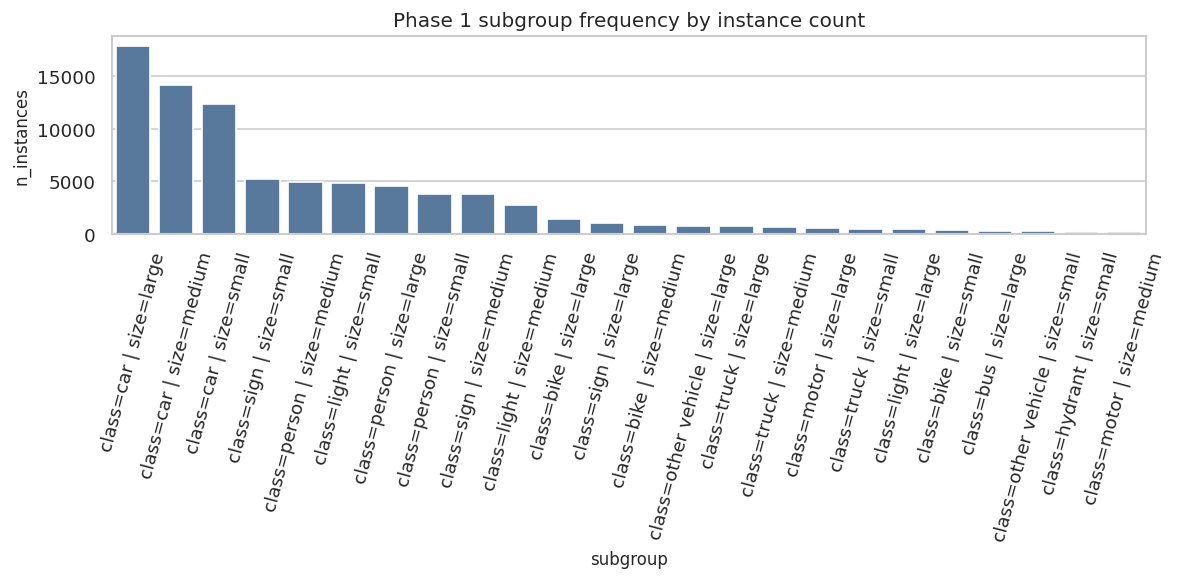

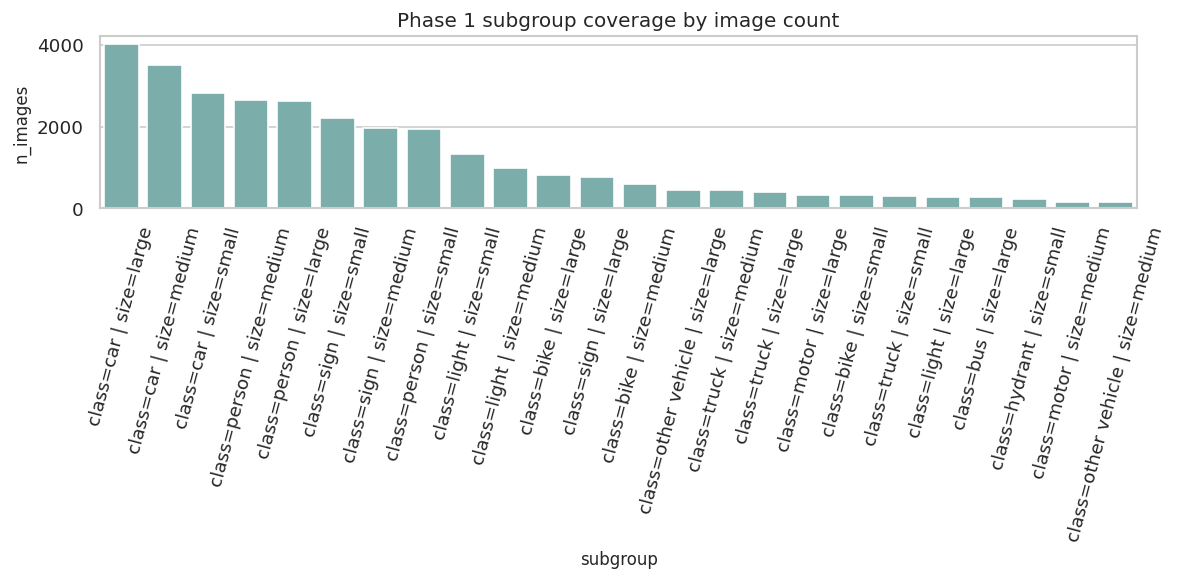

In [25]:
phase1_subgroup_frequency_df = build_subgroup_frequency_table(phase1_instance_table, phase1_image_subgroup_df)
display(phase1_subgroup_frequency_df.head(20))

phase1_instances_bar_fig = plot_bar(
    phase1_subgroup_frequency_df,
    value_col="n_instances",
    title="Phase 1 subgroup frequency by instance count",
)
phase1_images_bar_fig = plot_bar(
    phase1_subgroup_frequency_df,
    value_col="n_images",
    title="Phase 1 subgroup coverage by image count",
    color="#72b7b2",
)

plt.show()




## 2. Dominance analysis

This section evaluates whether subgroup appearance is central or incidental.
It summarizes dominance ratios, position profiles, and example images for the
selected subgroup.



,subgroup,mean_dominance,median_dominance,q75_dominance,q90_dominance,n_images
0,class=car | size=large,0.246947,0.227273,0.333333,0.437500,4006
1,class=deer | size=large,0.200000,0.200000,0.200000,0.200000,2
2,class=car | size=medium,0.197814,0.187500,0.264706,0.333333,3497
3,class=car | size=small,0.203916,0.181818,0.281250,0.382353,2824
4,class=light | size=small,0.175730,0.148148,0.229121,0.333333,1328
5,class=light | size=medium,0.140765,0.125000,0.181818,0.250000,997
6,class=sign | size=small,0.134701,0.111111,0.176471,0.250000,2205
7,class=person | size=medium,0.125535,0.095238,0.153846,0.250000,2652
8,class=person | size=large,0.136293,0.090909,0.166667,0.285714,2628
9,class=sign | size=medium,0.111948,0.090909,0.136364,0.200000,1967


,subgroup,n_instances,horizontal_center_share,grid_center_share,mean_center_distance,median_center_distance
0,class=car | size=small,12342,0.879193,0.878707,0.166475,0.135901
1,class=car | size=medium,14176,0.691309,0.690815,0.221834,0.183758
2,class=sign | size=small,5264,0.573708,0.553191,0.284674,0.241978
3,class=car | size=large,17909,0.356190,0.351723,0.355151,0.333712


Phase 1 selected subgroup: class=car | size=large


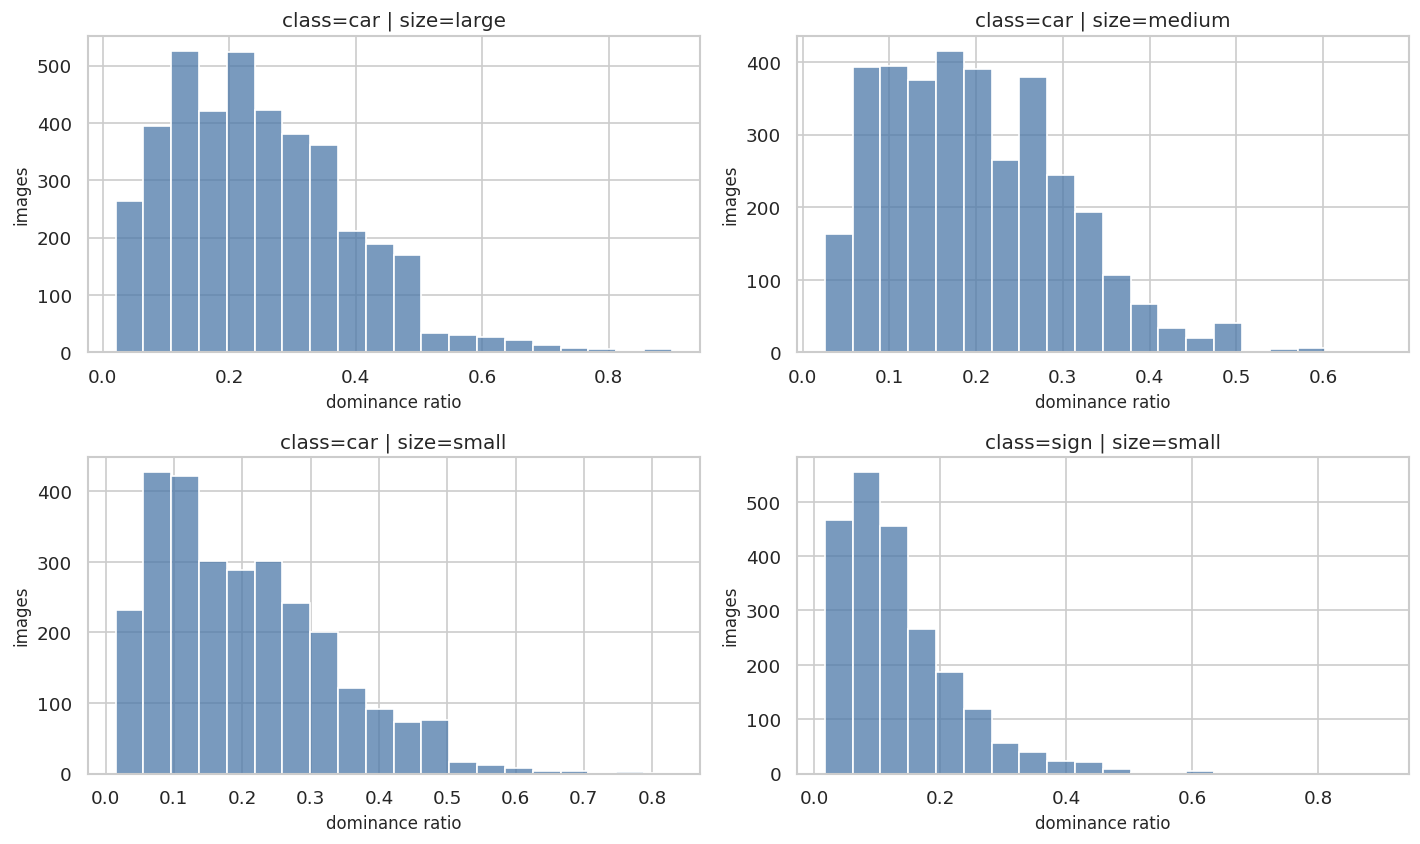

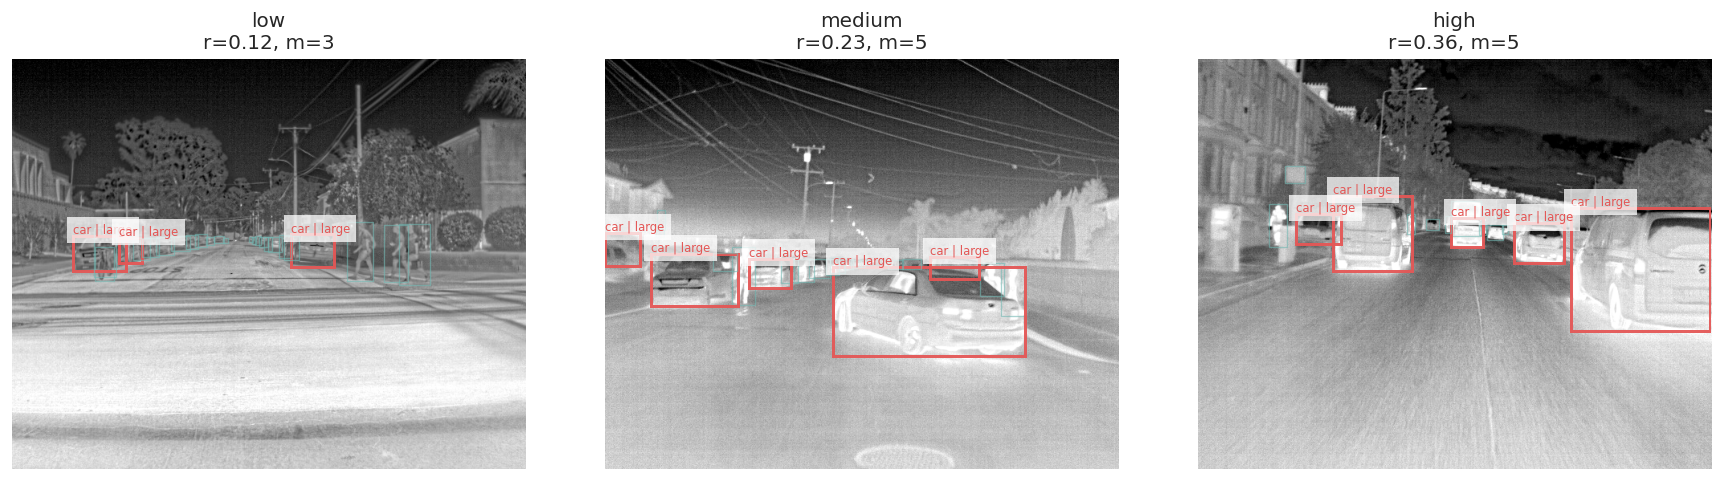

In [26]:
phase1_dominance_summary_df = build_dominance_summary(phase1_image_subgroup_df)
phase1_position_profile_df = build_position_profile(phase1_instance_table)
phase1_selected_subgroups = phase1_subgroup_frequency_df["subgroup"].head(MAX_EXAMPLE_SUBGROUPS).tolist()
phase1_selected_subgroup = choose_default_subgroup(phase1_subgroup_frequency_df, preferred=PHASE1_SELECTED_SUBGROUP)

display(phase1_dominance_summary_df.head(20))
display(
    phase1_position_profile_df.loc[
        phase1_position_profile_df["subgroup"].isin(phase1_selected_subgroups)
    ].reset_index(drop=True)
)
print("Phase 1 selected subgroup:", phase1_selected_subgroup)

phase1_dominance_hist_fig = plot_dominance_histograms(phase1_image_subgroup_df, phase1_selected_subgroups)
plt.show()

phase1_example_fig = plot_subgroup_examples(
    image_table,
    phase1_instance_table,
    phase1_image_subgroup_df,
    subgroup=phase1_selected_subgroup,
)
if phase1_example_fig is not None:
    plt.show()




## 3. Held-out size vs threshold

The benchmark hold-out set for subgroup `g*` is
`H(g*, tau) = {x : m_g*(x) >= 1 and r_g*(x) >= tau}`.
This sweep measures threshold sensitivity.



,subgroup,tau,heldout_n_images,heldout_fraction,mean_target_count,median_target_count,mean_dominance
0,class=car | size=large,0.1,3450,0.746753,4.962029,4.0,0.276113
1,class=car | size=large,0.2,2404,0.520346,5.878952,5.0,0.333558
2,class=car | size=large,0.3,1307,0.282900,6.993114,7.0,0.409922
3,class=car | size=large,0.4,593,0.128355,6.996627,7.0,0.493841
4,class=car | size=large,0.5,261,0.056494,6.505747,6.0,0.571690
5,class=car | size=large,0.6,83,0.017965,7.024096,7.0,0.687239
6,class=car | size=large,0.7,32,0.006926,6.906250,7.0,0.769947


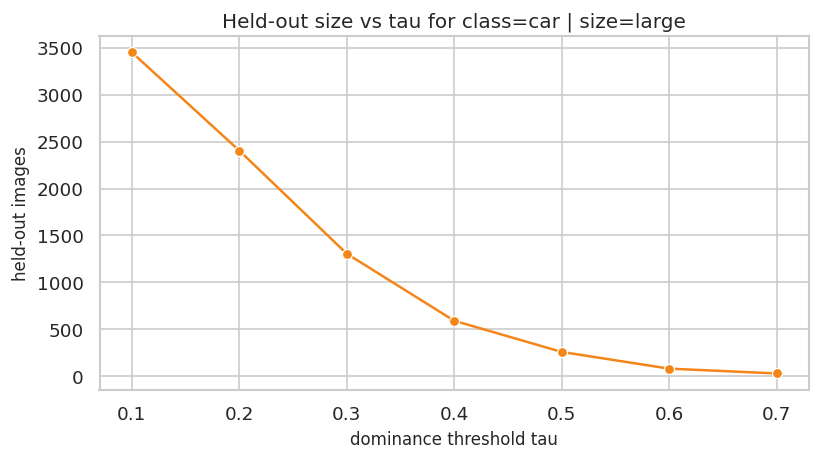

In [27]:
phase1_holdout_curve_df = compute_holdout_table(
    phase1_image_subgroup_df,
    phase1_image_stats_df,
    subgroup=phase1_selected_subgroup,
    thresholds=DOMINANCE_THRESHOLDS,
)
display(phase1_holdout_curve_df)

phase1_holdout_curve_fig = plot_holdout_curve(
    phase1_holdout_curve_df,
    title=f"Held-out size vs tau for {phase1_selected_subgroup}",
)
plt.show()




## 4. Collateral damage analysis

This section measures how much other subgroup content is removed when the
selected subgroup is held out at `tau = 0.5`.



,subgroup,tau,heldout_n_images,collateral_other_loss_frac
0,class=car | size=large,0.5,261,0.019953


,subgroup,count_before,count_after,count_loss,loss_fraction,is_target_subgroup
0,class=car | size=large,17909,16211,1698,0.094813,True
1,class=skateboard | size=small,24,22,2,0.083333,False
2,class=bus | size=large,311,289,22,0.070740,False
3,class=other vehicle | size=large,751,710,41,0.054594,False
4,class=person | size=large,4583,4366,217,0.047349,False
5,class=motor | size=large,541,521,20,0.036969,False
6,class=sign | size=large,1032,994,38,0.036822,False
7,class=person | size=medium,4901,4734,167,0.034075,False
8,class=person | size=small,3797,3702,95,0.025020,False
9,class=car | size=medium,14176,13822,354,0.024972,False


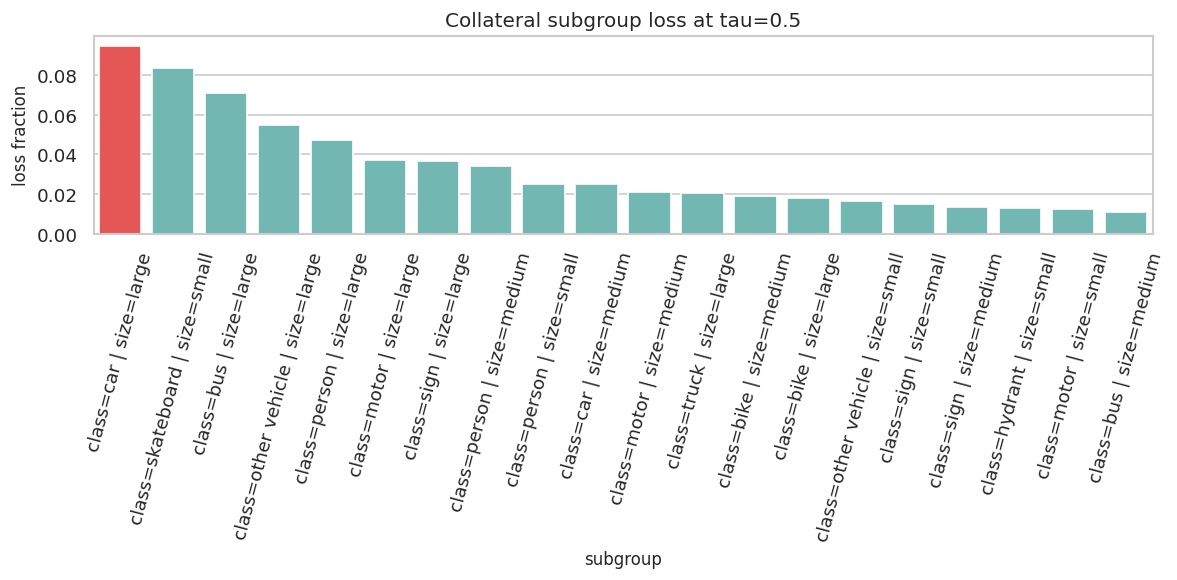

In [28]:
PHASE1_TAU = 0.5
phase1_collateral_damage_df, phase1_collateral_summary = compute_collateral_damage(
    phase1_instance_table,
    phase1_image_subgroup_df,
    subgroup=phase1_selected_subgroup,
    tau=PHASE1_TAU,
)

phase1_collateral_summary_df = pd.DataFrame([phase1_collateral_summary])
display(phase1_collateral_summary_df)
display(phase1_collateral_damage_df.head(20))

phase1_collateral_fig = plot_collateral_damage(
    phase1_collateral_damage_df,
    title=f"Collateral subgroup loss at tau={PHASE1_TAU:.1f}",
)
plt.show()




## 5. Train vs held-out regime comparison

This section checks whether the hold-out split isolates only the target
subgroup or also separates object count, density, and semantic context.



,partition,n_images,mean_total_object_count,median_total_object_count,mean_density,median_density
0,held_out,261,11.501916,10.0,0.138040,0.128192
1,train,4359,18.412939,17.0,0.105493,0.076614


,partition,class_label,count,fraction
0,held_out,bike,45,0.014990
1,held_out,bus,23,0.007662
2,held_out,car,2165,0.721186
3,held_out,hydrant,3,0.000999
4,held_out,light,26,0.008661
5,held_out,motor,25,0.008328
6,held_out,other vehicle,46,0.015323
7,held_out,person,479,0.159560
8,held_out,sign,168,0.055963
9,held_out,skateboard,2,0.000666


,partition,subgroup,count,fraction
0,held_out,class=bike | size=large,25,0.008328
1,held_out,class=bike | size=medium,16,0.005330
2,held_out,class=bike | size=small,4,0.001332
3,held_out,class=bus | size=large,22,0.007328
4,held_out,class=bus | size=medium,1,0.000333
5,held_out,class=car | size=large,1698,0.565623
6,held_out,class=car | size=medium,354,0.117921
7,held_out,class=car | size=small,113,0.037642
8,held_out,class=hydrant | size=small,3,0.000999
9,held_out,class=light | size=large,4,0.001332


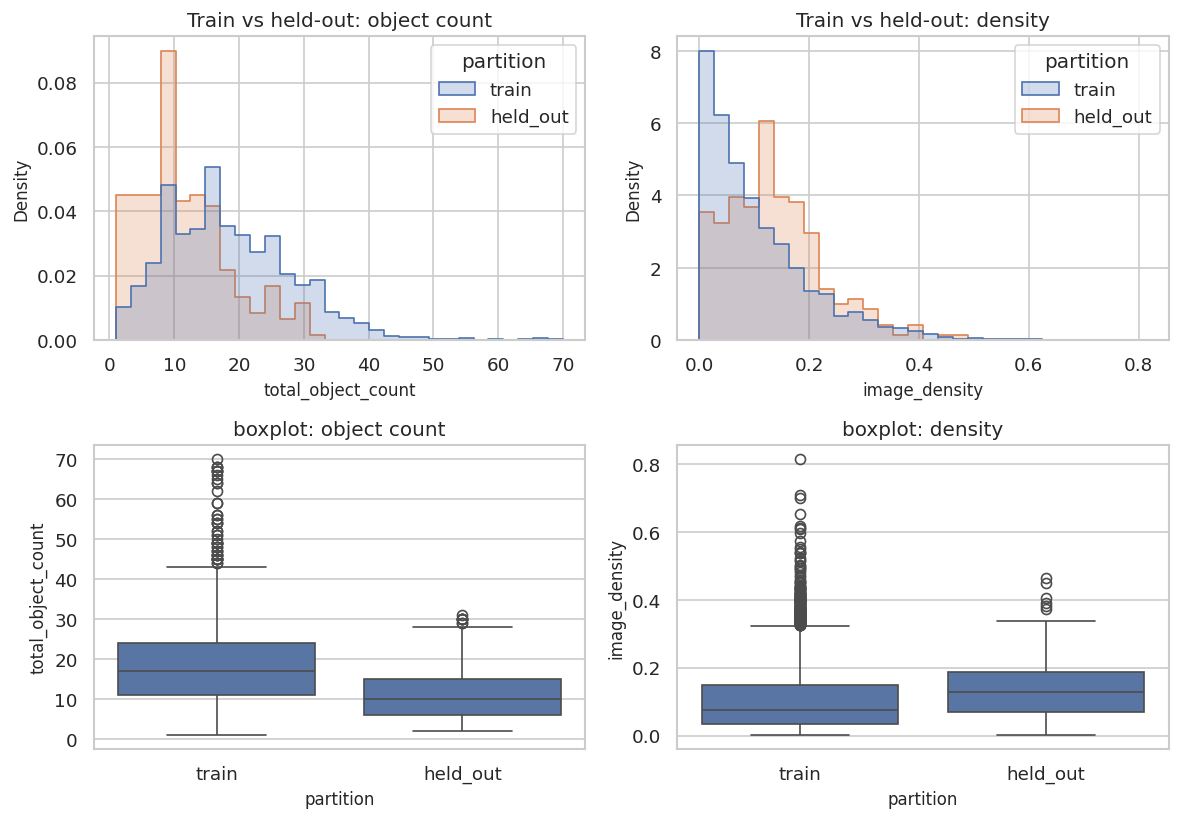

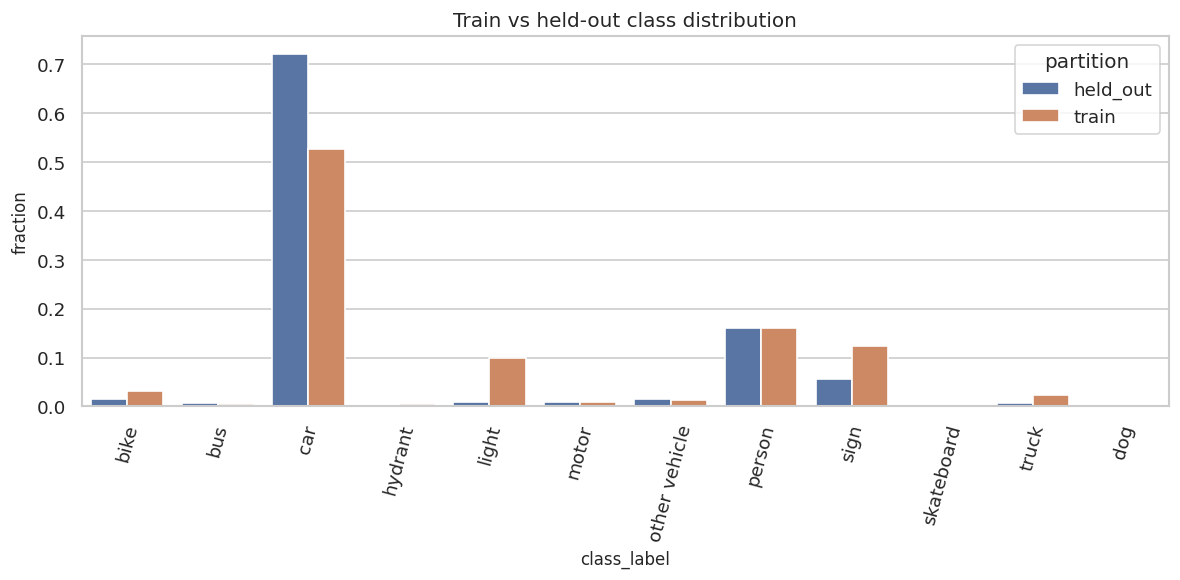

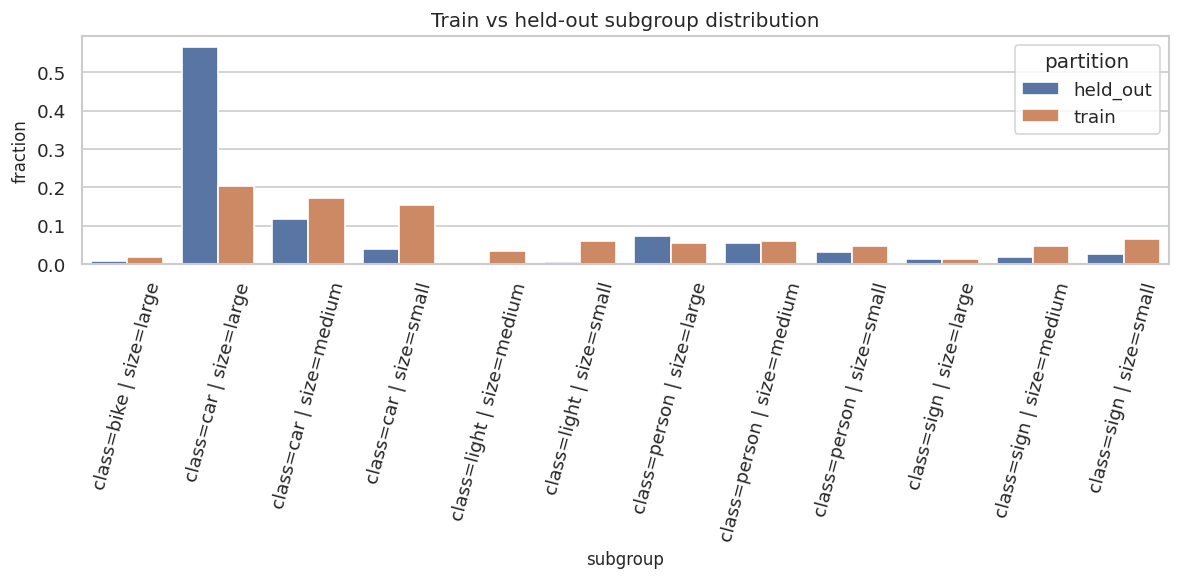

In [29]:
phase1_regime_tables = compare_train_vs_holdout(
    phase1_image_stats_df,
    phase1_instance_table,
    phase1_image_subgroup_df,
    subgroup=phase1_selected_subgroup,
    tau=PHASE1_TAU,
)

phase1_regime_numeric_summary_df = phase1_regime_tables["numeric_summary_df"]
phase1_class_distribution_df = phase1_regime_tables["class_distribution_df"]
phase1_subgroup_distribution_df = phase1_regime_tables["subgroup_distribution_df"]
phase1_cooccurring_class_distribution_df = phase1_regime_tables["cooccurring_class_distribution_df"]

display(phase1_regime_numeric_summary_df)
display(phase1_class_distribution_df.head(20))
display(phase1_subgroup_distribution_df.head(20))

phase1_regime_numeric_fig = plot_partition_numeric_distributions(
    phase1_regime_tables["image_partition_df"],
    title_prefix="Train vs held-out",
)
phase1_class_dist_fig = plot_partition_category_fractions(
    phase1_class_distribution_df,
    label_col="class_label",
    title="Train vs held-out class distribution",
    top_n=12,
)
phase1_subgroup_dist_fig = plot_partition_category_fractions(
    phase1_subgroup_distribution_df,
    label_col="subgroup",
    title="Train vs held-out subgroup distribution",
    top_n=12,
)
plt.show()




## 6. Dominant-group assignment analysis

This section tests whether assigning each image to a single dominant subgroup
is a reasonable simplification for this dataset.



,avg_subgroup_memberships_per_image,prop_images_with_more_than_one_subgroup,prop_images_with_tied_dominant_count
0,6.54026,0.996104,0.210606


,dominant_subgroup,n_images
0,class=car | size=large,1763
1,class=car | size=small,762
2,class=car | size=medium,734
3,class=light | size=small,300
4,class=person | size=large,191
5,class=person | size=medium,149
6,class=sign | size=small,136
7,class=light | size=medium,130
8,class=bike | size=large,121
9,class=person | size=small,104


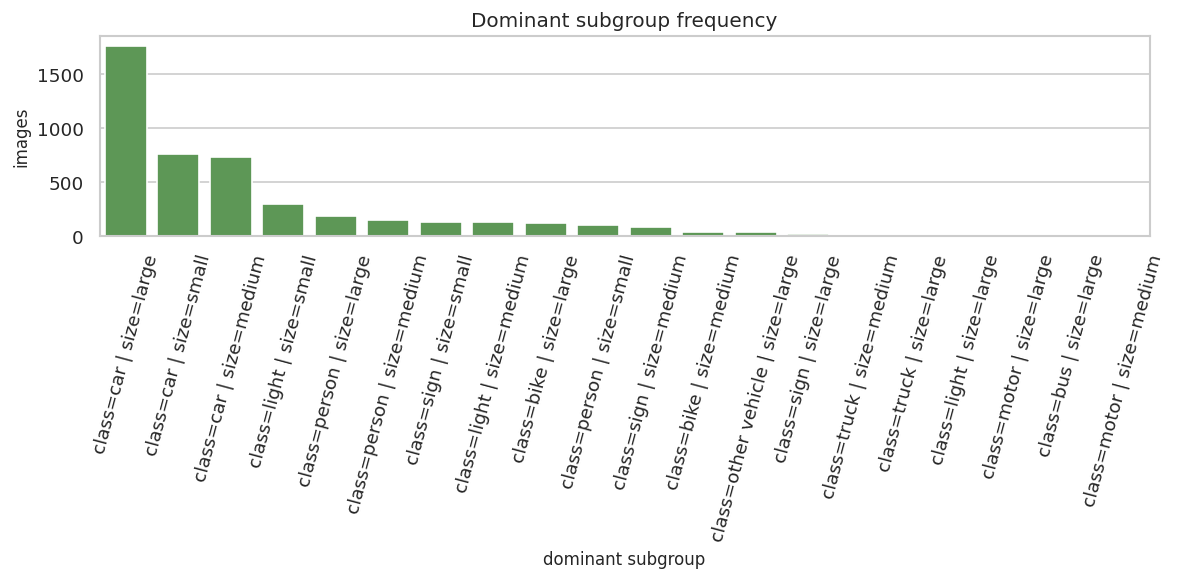

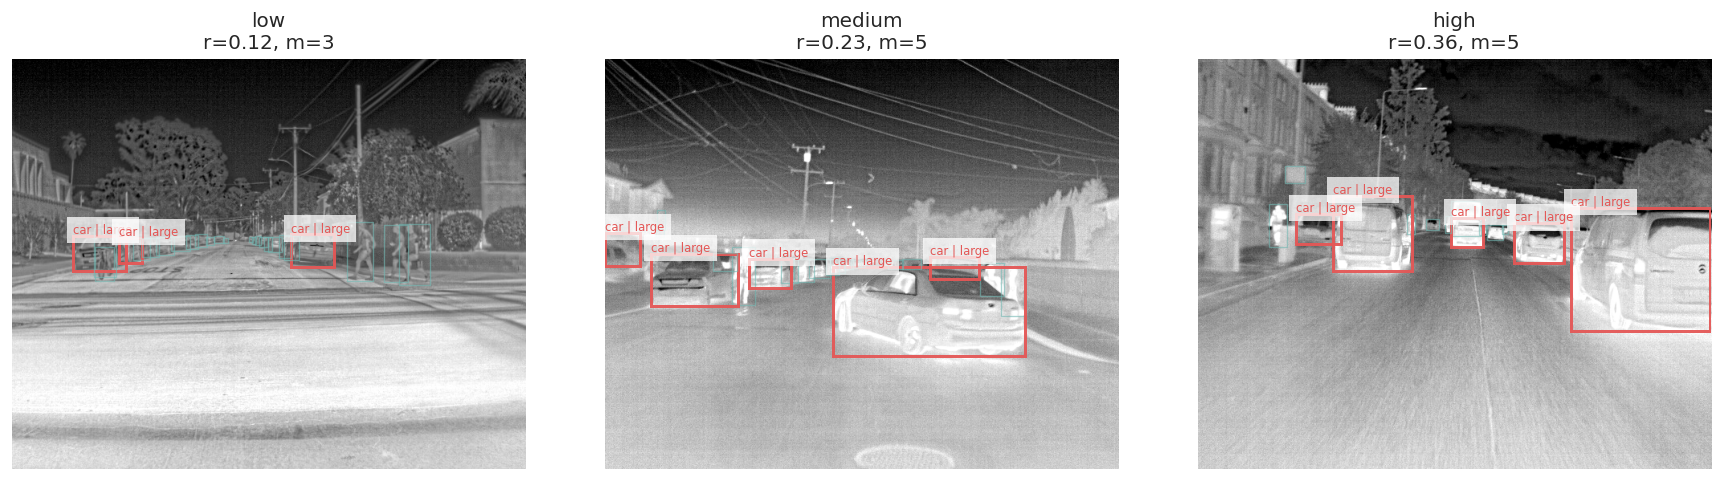

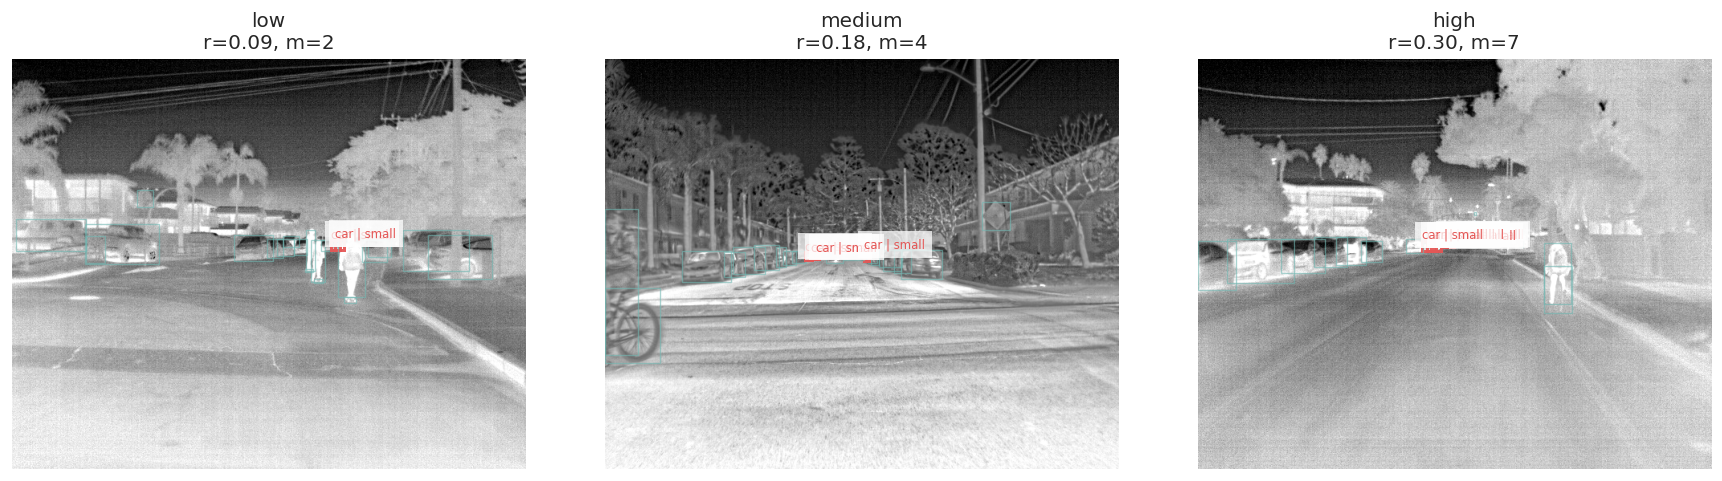

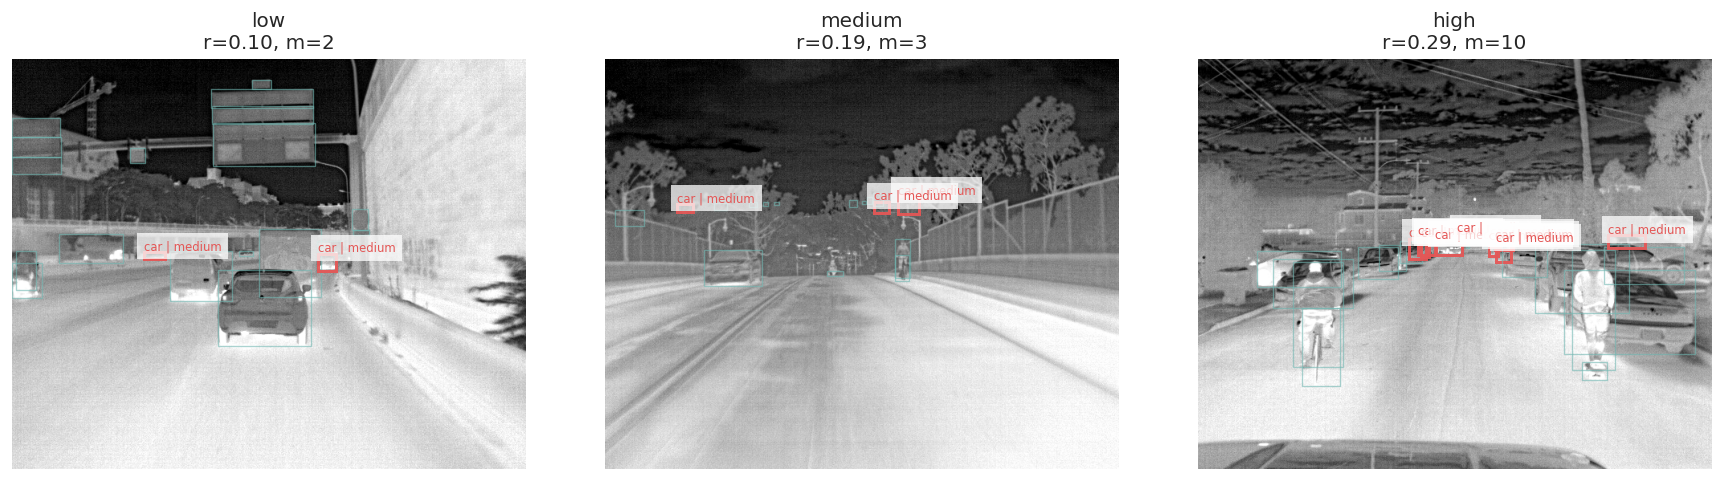

In [30]:
dominant_group_frequency_df, dominant_group_overview_df = build_dominant_group_summary(phase1_image_stats_df)
display(dominant_group_overview_df)
display(dominant_group_frequency_df.head(20))

dominant_group_frequency_fig = plot_dominant_group_frequency(dominant_group_frequency_df, top_n=20)
plt.show()

common_dominant_groups = dominant_group_frequency_df["dominant_subgroup"].dropna().head(3).tolist()
for dominant_group in common_dominant_groups:
    dominant_example_fig = plot_subgroup_examples(
        image_table,
        phase1_instance_table,
        phase1_image_subgroup_df,
        subgroup=dominant_group,
    )
    if dominant_example_fig is not None:
        plt.show()




## 7. Position-aware extension

Phase 2 extends the subgroup definition to `(class, size_bin, position_bin)`.
The analysis below repeats the key diagnostics with horizontal position bins.



,subgroup,n_instances,n_images,avg_instances_per_image_present
0,class=car | size=small | pos=center,10851,2624,4.135290
1,class=car | size=medium | pos=center,9800,3070,3.192182
2,class=car | size=large | pos=left,6693,2869,2.332869
3,class=car | size=large | pos=center,6379,3158,2.019949
4,class=car | size=large | pos=right,4837,2319,2.085813
5,class=car | size=medium | pos=left,3289,1608,2.045398
6,class=sign | size=small | pos=center,3020,1511,1.998676
7,class=light | size=small | pos=center,2860,1124,2.544484
8,class=person | size=small | pos=center,2634,1468,1.794278
9,class=person | size=medium | pos=center,2169,1503,1.443114


,subgroup,mean_dominance,median_dominance,q75_dominance,q90_dominance,n_images
0,class=deer | size=medium | pos=center,0.250000,0.250000,0.250000,0.250000,1
1,class=deer | size=large | pos=right,0.200000,0.200000,0.200000,0.200000,2
2,class=car | size=small | pos=center,0.191050,0.175735,0.259259,0.346154,2624
3,class=car | size=medium | pos=center,0.152082,0.136364,0.208333,0.269231,3070
4,class=bus | size=small | pos=right,0.112745,0.112745,0.139706,0.155882,2
5,class=car | size=large | pos=left,0.122318,0.105263,0.161290,0.222222,2869
6,class=car | size=large | pos=center,0.118768,0.100000,0.150000,0.219792,3158
7,class=light | size=small | pos=center,0.124668,0.100000,0.166667,0.238095,1124
8,class=car | size=small | pos=right,0.115703,0.100000,0.150000,0.223737,228
9,class=truck | size=large | pos=right,0.111932,0.100000,0.141234,0.200000,186


,subgroup,tau,heldout_n_images,collateral_other_loss_frac
0,class=car | size=large | pos=center,0.5,24,0.000442


Phase 2 selected subgroup: class=car | size=large | pos=center


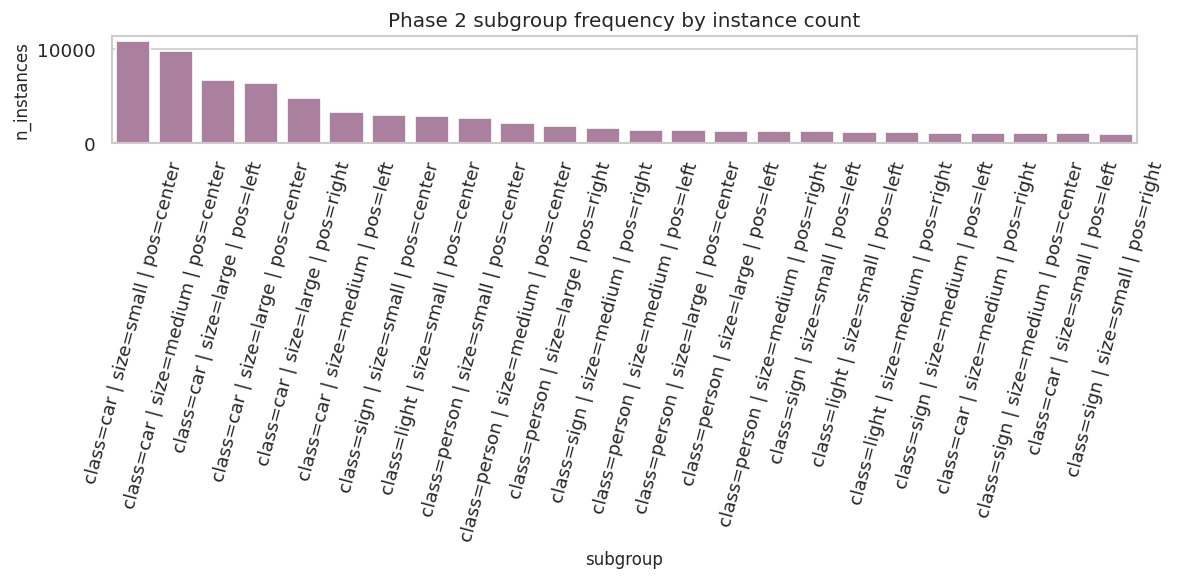

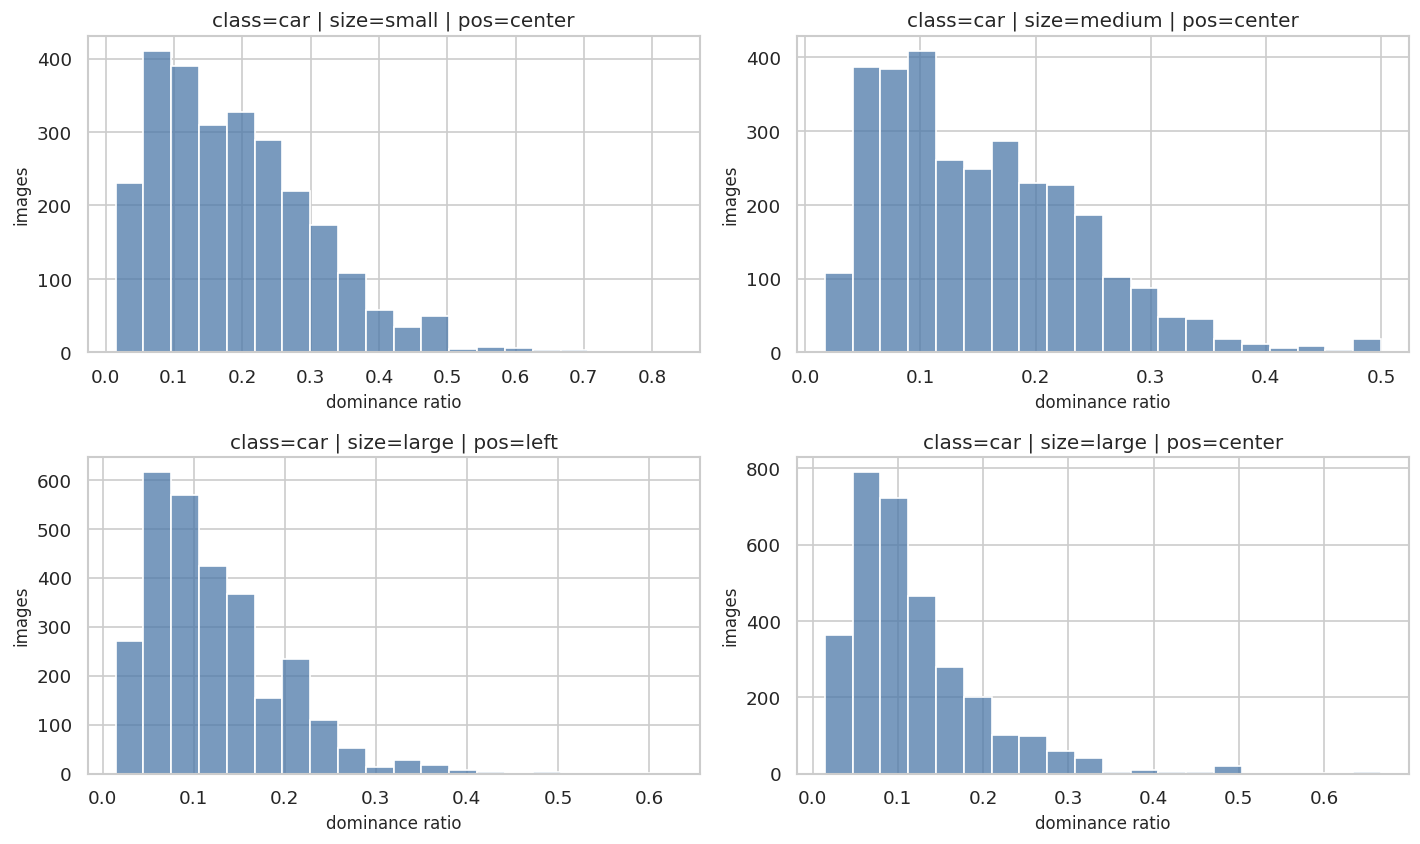

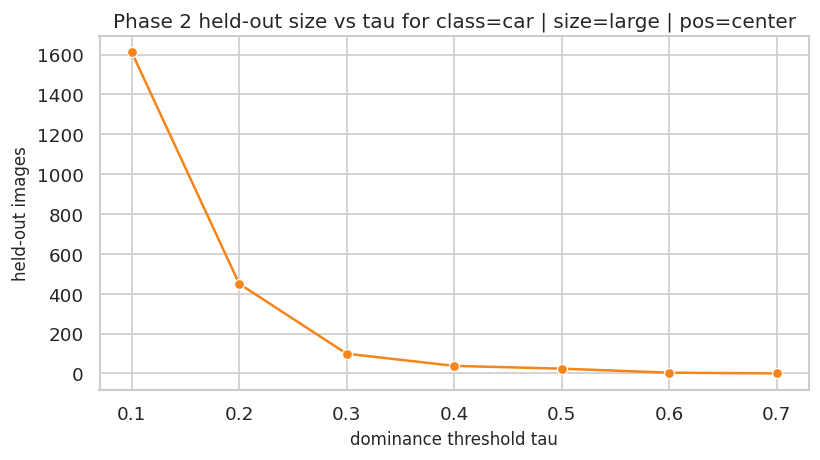

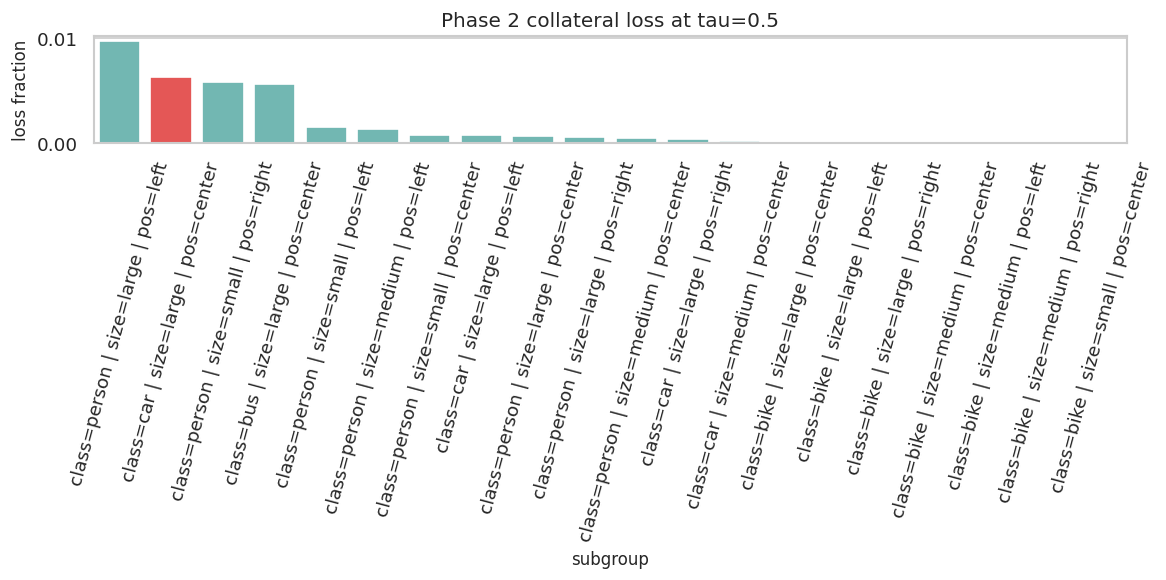

In [31]:
phase2_tables = build_analysis_tables(
    image_table,
    instance_table_raw,
    size_bin_method=SIZE_BIN_METHOD,
    size_bin_labels=SIZE_BIN_LABELS,
    fixed_size_bins=FIXED_SIZE_BINS,
    include_position=True,
    position_mode=POSITION_MODE,
)

phase2_instance_table = phase2_tables["instance_df"]
phase2_image_stats_df = phase2_tables["image_stats_df"]
phase2_image_subgroup_df = phase2_tables["image_subgroup_df"]

phase2_subgroup_frequency_df = build_subgroup_frequency_table(phase2_instance_table, phase2_image_subgroup_df)
phase2_dominance_summary_df = build_dominance_summary(phase2_image_subgroup_df)
phase2_selected_subgroups = phase2_subgroup_frequency_df["subgroup"].head(MAX_EXAMPLE_SUBGROUPS).tolist()
phase2_selected_subgroup = choose_default_subgroup(phase2_subgroup_frequency_df, preferred=PHASE2_SELECTED_SUBGROUP)
phase2_holdout_curve_df = compute_holdout_table(
    phase2_image_subgroup_df,
    phase2_image_stats_df,
    subgroup=phase2_selected_subgroup,
    thresholds=DOMINANCE_THRESHOLDS,
)
phase2_collateral_damage_df, phase2_collateral_summary = compute_collateral_damage(
    phase2_instance_table,
    phase2_image_subgroup_df,
    subgroup=phase2_selected_subgroup,
    tau=PHASE1_TAU,
)

display(phase2_subgroup_frequency_df.head(20))
display(phase2_dominance_summary_df.head(20))
display(pd.DataFrame([phase2_collateral_summary]))
print("Phase 2 selected subgroup:", phase2_selected_subgroup)

phase2_instances_bar_fig = plot_bar(
    phase2_subgroup_frequency_df,
    value_col="n_instances",
    title="Phase 2 subgroup frequency by instance count",
    color="#b279a2",
)
phase2_dominance_hist_fig = plot_dominance_histograms(phase2_image_subgroup_df, phase2_selected_subgroups)
phase2_holdout_curve_fig = plot_holdout_curve(
    phase2_holdout_curve_df,
    title=f"Phase 2 held-out size vs tau for {phase2_selected_subgroup}",
)
phase2_collateral_fig = plot_collateral_damage(
    phase2_collateral_damage_df,
    title=f"Phase 2 collateral loss at tau={PHASE1_TAU:.1f}",
)
plt.show()




## 8. Final benchmark-feasibility summary

Candidate subgroup feasibility is computed for phase 1 at `tau = 0.5` using
explicit thresholds on support, dominance, hold-out size, and collateral loss.



In [32]:
benchmark_feasibility_df = build_feasibility_table(
    phase1_subgroup_frequency_df,
    phase1_dominance_summary_df,
    phase1_image_stats_df,
    phase1_image_subgroup_df,
    phase1_instance_table,
    tau=0.5,
)

display(pd.DataFrame([FEASIBILITY_RULES]))
display(benchmark_feasibility_df.head(30))




,min_instances,min_images,min_median_dominance,min_holdout_images_tau_0_5,max_collateral_other_loss_frac_tau_0_5
0,100,40,0.5,25,0.35


,subgroup,n_instances,n_images,median_dominance,heldout_size_tau_0_5,collateral_other_loss_frac_tau_0_5,benchmark_feasible
0,class=car | size=large,17909,4006,0.227273,261,0.019953,False
1,class=person | size=large,4583,2628,0.090909,93,0.002262,False
2,class=car | size=small,12342,2824,0.181818,92,0.008883,False
3,class=person | size=medium,4901,2652,0.095238,57,0.001531,False
4,class=car | size=medium,14176,3497,0.187500,53,0.002909,False
5,class=person | size=small,3797,1939,0.090909,37,0.000982,False
6,class=light | size=small,4843,1328,0.148148,32,0.002512,False
7,class=sign | size=small,5264,2205,0.111111,16,0.000692,False
8,class=sign | size=medium,3793,1967,0.090909,15,0.000428,False
9,class=bike | size=large,1372,822,0.066667,10,0.000598,False


## 9. Per-class count distribution before vs after hold-out

This final cell compares the per-image class-count distribution before and
after removing the held-out images. It reuses the phase 1 hold-out by
default, but also accepts a precomputed `heldout_image_ids` variable.



,holdout_level,n_target_subgroups,tau,n_heldout_image_ids,heldout_fraction
0,phase1,1,0,4006,0.8671


,subgroup,heldout_n_images,mean_target_count,median_target_count,mean_dominance,median_dominance
0,class=car | size=large,4006,4.470544,4.0,0.246947,0.227273


,class_label,instance_count,n_images_before,n_images_after
0,bike,1,923,103
1,bike,2,339,30
2,bike,3,85,14
3,bike,4,30,0
4,bike,5,49,5
5,bike,6,19,1
6,bike,7,10,2
7,bike,8,6,4
8,bike,9,7,0
9,bike,10,5,3


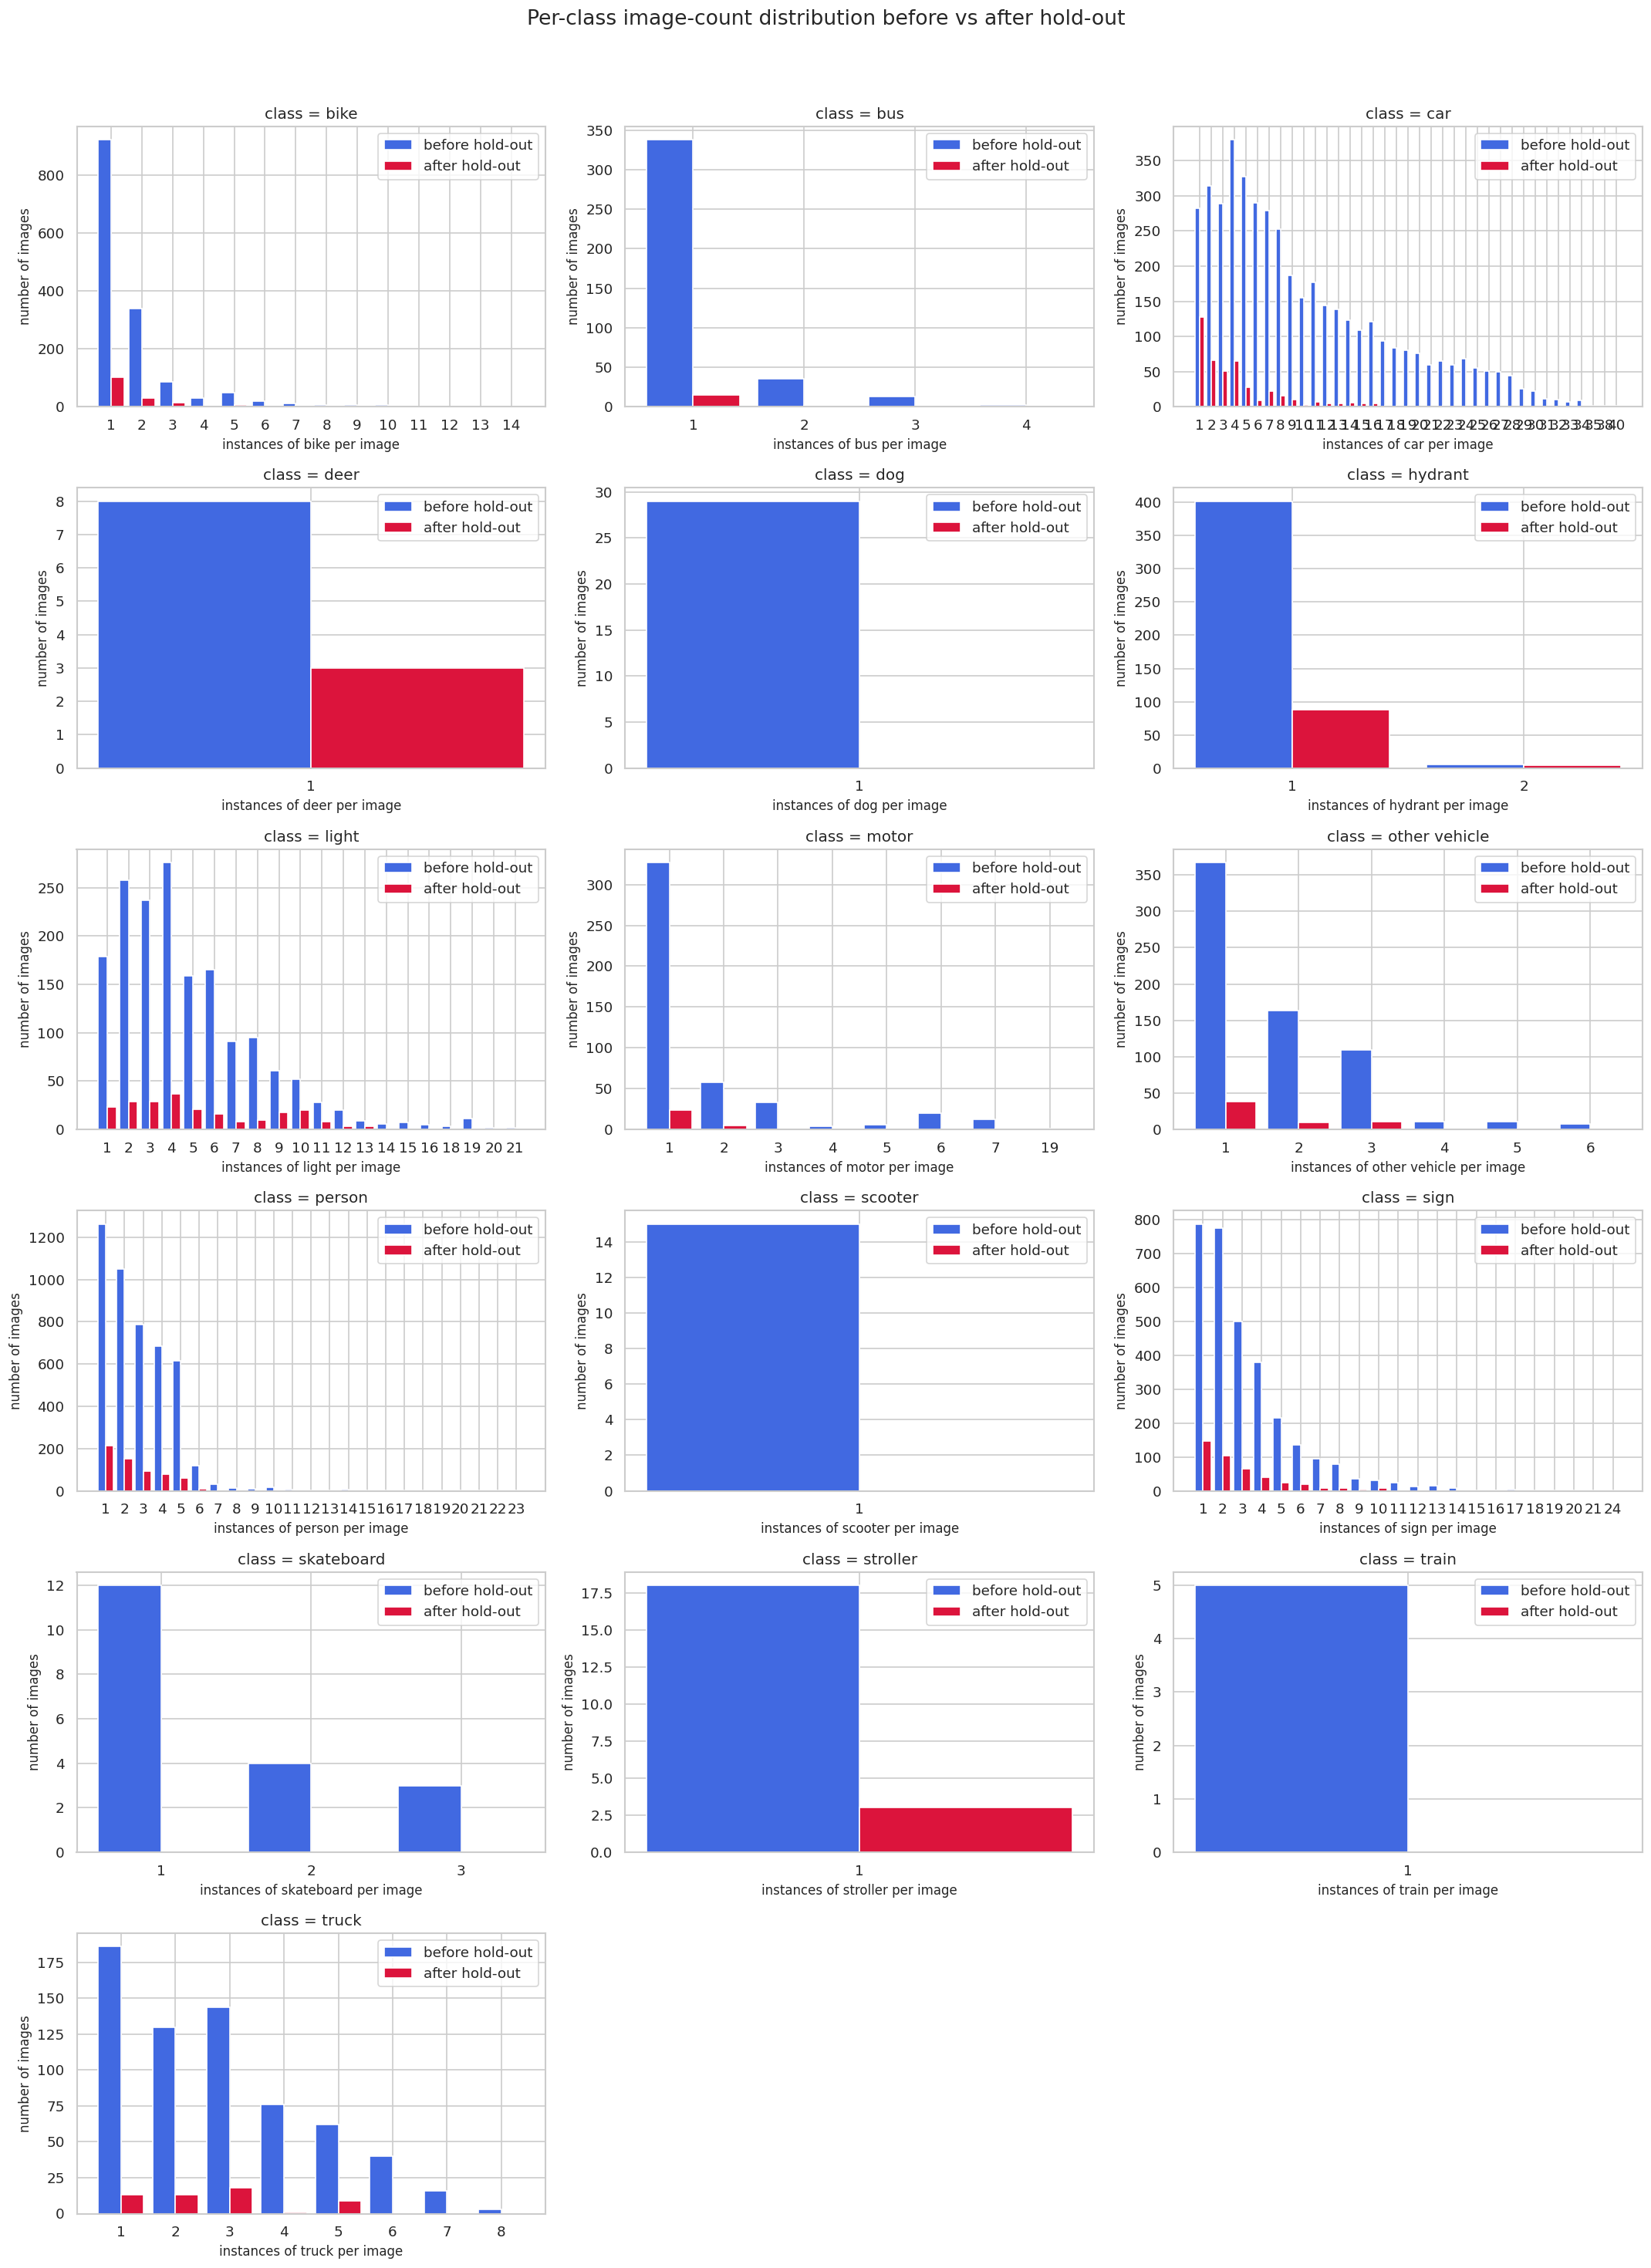

In [33]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------
# CONFIG
# -----------------------------
HOLDOUT_LEVEL = "phase1"  # "phase1" or "phase2"
TARGET_SUBGROUPS = [phase1_selected_subgroup]
HOLDOUT_TAU = 0
IMAGE_COL = "image_id"
CLASS_COL = "class_label"
MAX_COLS = 3
INCLUDE_ZERO = False
FIGSIZE_PER_AX = (6, 4)

# -----------------------------
# SELECT TABLES
# -----------------------------
if HOLDOUT_LEVEL == "phase1":
    holdout_image_subgroup_df = phase1_image_subgroup_df.copy()
    holdout_image_stats_df = phase1_image_stats_df.copy()
    count_instance_df = phase1_instance_table.copy()
elif HOLDOUT_LEVEL == "phase2":
    holdout_image_subgroup_df = phase2_image_subgroup_df.copy()
    holdout_image_stats_df = phase2_image_stats_df.copy()
    count_instance_df = phase1_instance_table.copy()
else:
    raise ValueError(f"Unsupported HOLDOUT_LEVEL: {HOLDOUT_LEVEL}")

# -----------------------------
# CHECKS
# -----------------------------
required_cols = {IMAGE_COL, CLASS_COL}
missing = required_cols - set(count_instance_df.columns)
if missing:
    raise ValueError(f"Count table is missing required columns: {missing}")

available_subgroups = set(holdout_image_subgroup_df["subgroup"].dropna().unique().tolist())
missing_subgroups = sorted(set(TARGET_SUBGROUPS) - available_subgroups)
if missing_subgroups:
    raise ValueError(f"Target subgroups not found in {HOLDOUT_LEVEL}: {missing_subgroups}")

target_holdout_rows = holdout_image_subgroup_df.loc[
    holdout_image_subgroup_df["subgroup"].isin(TARGET_SUBGROUPS)
].copy()
target_holdout_rows = target_holdout_rows.loc[
    (target_holdout_rows["subgroup_count"] >= 1) & (target_holdout_rows["dominance_ratio"] >= HOLDOUT_TAU)
].copy()

heldout_image_keys = sorted(target_holdout_rows["image_key"].unique().tolist())
heldout_image_ids = set(
    holdout_image_stats_df.loc[holdout_image_stats_df["image_key"].isin(heldout_image_keys), "image_id"].tolist()
)

target_holdout_summary_df = (
    target_holdout_rows.groupby("subgroup")
    .agg(
        heldout_n_images=("image_key", "nunique"),
        mean_target_count=("subgroup_count", "mean"),
        median_target_count=("subgroup_count", "median"),
        mean_dominance=("dominance_ratio", "mean"),
        median_dominance=("dominance_ratio", "median"),
    )
    .reset_index()
    .sort_values(["heldout_n_images", "mean_dominance"], ascending=False)
)

# -----------------------------
# BUILD IMAGE-LEVEL CLASS COUNTS
# -----------------------------
image_class_counts = (
    count_instance_df.groupby([IMAGE_COL, CLASS_COL]).size().rename("instance_count").reset_index()
)

all_images = pd.DataFrame({IMAGE_COL: count_instance_df[IMAGE_COL].drop_duplicates().tolist()})
all_classes = pd.DataFrame({CLASS_COL: sorted(count_instance_df[CLASS_COL].dropna().unique().tolist())})

if INCLUDE_ZERO:
    full_grid = (
        all_images.assign(_tmp=1).merge(all_classes.assign(_tmp=1), on="_tmp").drop(columns="_tmp")
    )
    image_class_counts = (
        full_grid.merge(image_class_counts, on=[IMAGE_COL, CLASS_COL], how="left").fillna({"instance_count": 0})
    )
    image_class_counts["instance_count"] = image_class_counts["instance_count"].astype(int)

image_class_counts["split_state"] = np.where(
    image_class_counts[IMAGE_COL].isin(heldout_image_ids), "heldout", "train_after"
)

# -----------------------------
# DISTRIBUTION TABLES
# -----------------------------
before_dist = (
    image_class_counts.groupby([CLASS_COL, "instance_count"]).size().rename("n_images_before").reset_index()
)

after_dist = (
    image_class_counts[~image_class_counts[IMAGE_COL].isin(heldout_image_ids)]
    .groupby([CLASS_COL, "instance_count"])
    .size()
    .rename("n_images_after")
    .reset_index()
)

count_dist_df = (
    before_dist.merge(after_dist, on=[CLASS_COL, "instance_count"], how="outer").fillna(0).sort_values(
        [CLASS_COL, "instance_count"]
    )
)

count_dist_df["n_images_before"] = count_dist_df["n_images_before"].astype(int)
count_dist_df["n_images_after"] = count_dist_df["n_images_after"].astype(int)

display(
    pd.DataFrame(
        [
            {
                "holdout_level": HOLDOUT_LEVEL,
                "n_target_subgroups": len(TARGET_SUBGROUPS),
                "tau": HOLDOUT_TAU,
                "n_heldout_image_ids": len(heldout_image_ids),
                "heldout_fraction": len(heldout_image_ids) / max(all_images[IMAGE_COL].nunique(), 1),
            }
        ]
    )
)
display(target_holdout_summary_df)
display(count_dist_df.head(30))

# -----------------------------
# PLOT: one chart per class
# -----------------------------
classes = sorted(count_dist_df[CLASS_COL].unique().tolist())
n_classes = len(classes)
n_cols = min(MAX_COLS, max(n_classes, 1))
n_rows = math.ceil(max(n_classes, 1) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(FIGSIZE_PER_AX[0] * n_cols, FIGSIZE_PER_AX[1] * n_rows),
    squeeze=False,
)

for ax, cls in zip(axes.flat, classes):
    sub = count_dist_df[count_dist_df[CLASS_COL] == cls].copy()

    if not INCLUDE_ZERO:
        sub = sub[sub["instance_count"] > 0]

    sub = sub.sort_values("instance_count")

    x = np.arange(len(sub))
    width = 0.42

    ax.bar(
        x - width / 2,
        sub["n_images_before"],
        width=width,
        color="royalblue",
        label="before hold-out",
    )
    ax.bar(
        x + width / 2,
        sub["n_images_after"],
        width=width,
        color="crimson",
        label="after hold-out",
    )

    ax.set_title(f"class = {cls}")
    ax.set_xlabel(f"instances of {cls} per image")
    ax.set_ylabel("number of images")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["instance_count"].astype(int).tolist(), rotation=0)
    ax.legend()

for ax in axes.flat[n_classes:]:
    ax.axis("off")

plt.suptitle("Per-class image-count distribution before vs after hold-out", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()
